[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# 투빅스 25&26기 2주차 2교시 — Deep Learning 과제 [sklearn `digits` 손글씨 분류]


## 과제 목적

이번 과제는 `sklearn`의 `digits` 데이터셋을 이용해 **MLP를 직접 학습**하고, DNN의 세 가지 고질병인 **Vanishing Gradient · Overfitting · Optimization**을 실제 실험 결과로 확인하는 프로젝트입니다. §1.1에서는 데이터를 확인하고 train / validation / test로 분리하며, §1.2에서는 PyTorch로 미니배치 SGD 학습 루프를 완성합니다. 이어지는 §1.3~1.5에서는 활성화 함수, 규제 방법, optimizer를 하나씩 바꾸며 강의의 설명이 실제 학습 곡선과 수치에서 어떻게 나타나는지 검증합니다. 마지막 심화(§2)에서는 "활성화 함수가 없으면 층을 쌓아도 선형모델"이라는 주장을 직접 확인하고, 파라미터 수를 맞춘 Wide vs Deep 비교를 통해 "Deep이 항상 더 좋은가"를 본인 실험으로 판단합니다.

## 주의 사항
각 코드 셀의 빈칸(`# TODO: ____`, `____`)을 채우며 **"지금 어느 단계에서 무엇을 하고 있는가"**를 확인하세요. 앞 단계에서 만든 변수와 함수가 뒤 절에서 계속 사용되므로 **맨 위 셀부터 순서대로** 실행해야 합니다.


## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — §1.3~1.5의 실험 결과 그래프와 본인 해석을 옮겨 정리


---

## 0. 환경 설정 — 라이브러리, 시드, 데이터 로드

이번 과제는 **별도 파일 업로드가 필요 없습니다.** scikit-learn에 내장된 **`load_digits()`** 를 씁니다.

- **무슨 데이터?** 손글씨 숫자 이미지 **1,797장**. 각 이미지는 **8×8 = 64 픽셀**, 픽셀 값은 **0~16**의 정수(밝기). 정답은 **0~9의 10개 클래스**입니다.
- **왜 이 데이터?** 강의의 마지막 슬라이드 구조(`Input → Hidden → Output`, `# of nodes: 변수 개수(d) / 자유 / Task에 의존`)를 그대로 적용할 수 있습니다. 입력 노드는 **64개(픽셀 수 = d)**, 출력 노드는 **10개(클래스 수 = Task에 의존)**, 은닉층은 **자유**입니다. 그리고 크기가 작아 Colab CPU에서도 실험 하나가 몇 초면 끝나므로, **여러 조건을 비교**하는 이번 과제에 적합합니다.

이 셀에서 하는 일은 세 가지입니다.

**1) 라이브러리 import.** 이후 모든 셀이 여기서 불러온 이름(`np`, `torch`, `nn` 등)을 씁니다. 한 번만 실행하면 됩니다.

**2) `MY_SEED` 설정.** *시드(seed)* 는 난수 생성기의 출발점입니다. 딥러닝에는 무작위가 **최소 세 군데** 들어갑니다 — ① **가중치 초기화**, ② **train/val/test 분할**, ③ **미니배치 셔플 순서**. 시드를 고정해야 재현이 되고 채점이 가능합니다.

**3) 데이터 로드.** `load_digits()`는 sklearn 패키지 안에 들어 있어 인터넷 없이도 즉시 로드됩니다.

> 시드를 고정한다고 결과가 **편향**되는 것은 아닙니다. 무작위 절차를 **재현 가능**하게 만들 뿐입니다.

In [28]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED =  8031          # TODO: 학번 뒷 4자리
np.random.seed(MY_SEED)        # TODO: NumPy 난수 고정
torch.manual_seed(MY_SEED)     # TODO: PyTorch 난수 고정 (가중치 초기화·셔플에 영향)

# (2) 데이터 로드 — sklearn 내장 데이터라 다운로드/업로드가 필요 없다
digits = load_digits()
X = digits.data          # (n_samples, 64)  픽셀 밝기 0~16
y = digits.target        # (n_samples,)     정답 클래스 0~9

# (3) 로드 확인
print("PyTorch version :", torch.__version__)
print("MY_SEED         :", MY_SEED)
print("X shape (샘플수, 픽셀수) :", X.shape)      # 기대: (1797, 64)
print("y shape                  :", y.shape)
print("클래스 종류              :", np.unique(y))
print("픽셀 값 범위             :", X.min(), "~", X.max())

PyTorch version : 2.11.0+cpu
MY_SEED         : 8031
X shape (샘플수, 픽셀수) : (1797, 64)
y shape                  : (1797,)
클래스 종류              : [0 1 2 3 4 5 6 7 8 9]
픽셀 값 범위             : 0.0 ~ 16.0


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `X.shape`는 무엇인가요? **샘플 수**와 **픽셀 수**를 본인이 본 실제 숫자로 적으세요.
- X.shape는 전체 손글씨 이미지 샘플 데이터를 의미하며 샘플 수는 1797개이고 픽셀수는 64개입니다.
2. 강의 마지막 NN Structure 표(p.28)에 따르면 **Input layer의 노드 수 = 변수 개수(d)**, **Output layer의 노드 수 = Task에 의존**입니다. 이 데이터에서 입력 노드 수와 출력 노드 수는 각각 몇 개여야 하나요? 그 근거를 위 출력값으로 대세요.
- Input 노드수는 64개여야합니다. 이미지 한장 당 64개의 픽셀의 밝기 데이터를 입력으로 받기 때문입니다. Output layer의 노드 수는 10개로 분류해야할 숫자가 0에서 9까지 총 10개의 Task로 구성되어 있기 때문입니다.

3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `X.shape`가 달라질까요? 한 줄로 설명하세요.

> 힌트(3번): 시드는 *무작위 절차*(초기화·셔플·분할)에만 영향을 줍니다. 패키지에 들어 있는 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.
- 시드는 무작위 절차에만 영향을 주므로 load_digits()으로 이미 저장된 정적 데이터를 로드하는 과정에는 영향을 주지 않습니다. 따라서 X.shape는 달라지지 않습니다.

---

# 1. 필수 과제

아래 1.1~1.5를 **순서대로** 완성합니다. 앞 단계에서 만든 변수(`X_train_s`, `train_model` 등)를 뒤 단계가 그대로 쓰므로 **위에서부터 차례로** 실행하세요.

흐름은 다음과 같습니다.

```
1.1 데이터 준비  →  1.2 PyTorch MLP 학습 (미니배치 SGD 루프)
                             ↓
          1.3 Vanishing Gradient  /  1.4 Overfitting  /  1.5 Optimization
             (강의 4장 "Critical Issues & Remedies"를 각각 실험으로 확인)
```

---

### 1.1 데이터 만나기 — 이미지 확인과 train / val / test 분리

먼저 데이터를 **눈으로** 봅니다. 8×8 배열을 이미지로 그려 "이게 정말 손글씨 숫자인가"를 확인하고, 클래스가 한쪽으로 쏠려 있지는 않은지 셉니다.

그다음 데이터를 **세 덩어리**로 나눕니다. 1주차에서는 train/test 둘로만 나눴지만, 딥러닝에서는 **validation(검증) 세트가 하나 더** 필요합니다.

| 세트 | 쓰는 곳 | 강의 연결 |
|---|---|---|
| **train** | 가중치를 학습(업데이트)하는 데이터 | 4장 Remedy ①: 미니배치 SGD가 도는 곳 |
| **validation** | **학습 중** 성능을 감시하며 언제 멈출지·어떤 설정이 나은지 고르는 데이터 | 4장 Issue 2 Remedy ①: Early Stopping의 판단 기준 |
| **test** | **마지막에 딱 한 번** 최종 성능을 재는 데이터 | 일반화(Generalization) 성능의 최종 보고 |

**Early Stopping은 val loss를 보고 멈추는 방법**입니다(강의 p.40). 그런데 만약 test로 멈출 시점을 고르면, test는 더 이상 "본 적 없는 데이터"가 아니게 되어 성능이 부풀려집니다 — 이것이 **데이터 누수(data leakage)** 입니다. 그래서 세 덩어리가 필요합니다.

**표준화(StandardScaler)** 도 같은 이유로 조심해야 합니다. 각 픽셀을 평균 0·표준편차 1로 맞추면 학습이 훨씬 안정적인데(값의 스케일이 제각각이면 gradient도 제각각), **평균과 표준편차는 반드시 train에서만 계산(`fit`)** 하고 val/test에는 그 값을 **적용(`transform`)** 만 해야 합니다. test의 평균까지 써서 스케일링하면 test 정보가 학습 과정에 새어 들어갑니다.

> ⚠️ 참고: `digits`에는 항상 0인 픽셀(테두리)이 있어 표준편차가 0인 열이 생깁니다. sklearn은 이런 열을 0으로 나누지 않고 그대로 두므로 에러는 나지 않습니다.


클래스별 샘플 수: [178 182 177 183 181 182 181 179 174 180]
가장 많은 클래스 / 가장 적은 클래스: 183 / 174


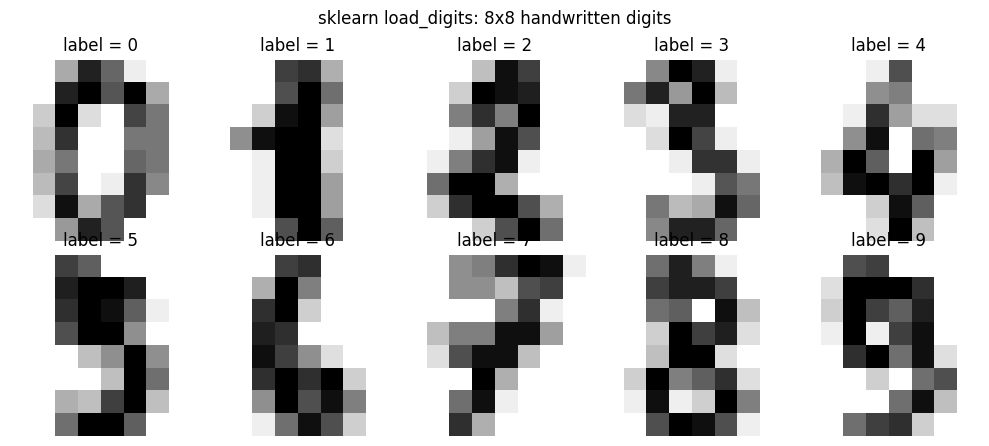


분할 결과  train: (1078, 64)  val: (359, 64)  test: (360, 64)
표준화 후 train 평균/표준편차 (전체 픽셀 기준): 0.0000 / 0.9763
표준화 후 test  평균/표준편차 (전체 픽셀 기준): 0.0026 / 1.0278   <- 정확히 0/1이 아닌 것이 정상

텐서 변환 완료: torch.Size([1078, 64]) torch.Size([1078]) torch.int64


In [ ]:
# ── 1.1 데이터 확인 & 분할 ─────────────────────────────────────

# (1) 클래스별 개수 세기 — 한쪽으로 쏠려 있는가?
print("클래스별 샘플 수:", np.bincount(y))     # TODO: 정답 배열을 넣어 클래스별 개수를 센다
print("가장 많은 클래스 / 가장 적은 클래스:", np.bincount(y).max(), "/", np.bincount(y).min())

# (2) 이미지 10장 눈으로 확인 (보일러플레이트 — 그대로 두세요)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"label = {y[i]}")
    ax.axis("off")
plt.suptitle("sklearn load_digits: 8x8 handwritten digits")
plt.tight_layout()
plt.show()

# (3) train : val : test = 60 : 20 : 20 으로 두 번에 걸쳐 분할
#     stratify=... 를 주면 각 세트의 클래스 비율이 원본과 같게 유지된다.
# TODO: 먼저 전체를 train(60%) / 임시(40%)로 나눈다. random_state 는 MY_SEED.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
# TODO: 임시(40%)를 다시 반으로 갈라 val(20%) / test(20%)로 만든다.
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=MY_SEED, stratify=y_tmp
)
print("\n분할 결과  train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

# (4) 표준화 — 평균/표준편차는 반드시 train 에서만 학습(fit)한다!
scaler = StandardScaler()
# TODO: train 에만 fit 하고, 세 세트 모두 transform 한다. (fit_transform 을 val/test 에 쓰면 누수!)
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("표준화 후 train 평균/표준편차 (전체 픽셀 기준): "
      f"{X_train_s.mean():.4f} / {X_train_s.std():.4f}")
print("표준화 후 test  평균/표준편차 (전체 픽셀 기준): "
      f"{X_test_s.mean():.4f} / {X_test_s.std():.4f}   <- 정확히 0/1이 아닌 것이 정상")

# (5) PyTorch 텐서로 변환 (실수형 X, 정수형 라벨 y)
Xtr = torch.tensor(X_train_s, dtype=torch.float32); ytr = torch.tensor(y_train, dtype=torch.long)
Xva = torch.tensor(X_val_s,   dtype=torch.float32); yva = torch.tensor(y_val,   dtype=torch.long)
Xte = torch.tensor(X_test_s,  dtype=torch.float32); yte = torch.tensor(y_test,  dtype=torch.long)
print("\n텐서 변환 완료:", Xtr.shape, ytr.shape, ytr.dtype)

**해석 질문 1.1 (본인이 출력한 실제 값을 인용해 답하세요)**

1. train / val / test 각각 몇 개의 샘플이 배정되었나요? 클래스별 개수(`np.bincount(y)`)를 보고, 이 데이터가 1주차 Framingham의 `TenYearCHD`(양성 약 15%)처럼 **불균형**한지 아닌지 판단하세요. 불균형하지 않다면, "무조건 한 클래스로만 찍는" 모델의 정확도는 몇 % 정도일까요?
- train에는 1078개, val에는 359개, test에는 360개의 샘플이 배정되었다. 클래스별 샘플 수가 180개 안팎이기 때문에 균형한 데이터이다. 10개의 클래스이므로 무조건으로 한 클래스로만 찍는 모델의 정확도는 10%일 것이다.

2. `X_test_s`의 평균이 정확히 0이 **아닌** 이유는 무엇인가요? 만약 `scaler.fit_transform(X_test)` 로 test에도 따로 fit 했다면 평균은 0이 되었을 텐데, 그렇게 하면 **왜 안 되는지** '데이터 누수' 개념으로 설명하세요.
- train 데이터 기준으로만 학습한뒤 test 데이터에는 변환만 적용했기 때문에 평균이 0이 되지 않는다. test에 fit을 적용해버리면 평균과, 표준편차를 구하는 과정에서 test 정보가 모델 평가에 들어와버리는 데이터 누수가 발생한다.
3. train / val / test **세 덩어리**가 필요한 이유를, 강의 p.40 **Early Stopping**과 연결해 한 문장으로 쓰세요. (힌트: 멈출 시점을 무엇으로 고르고, 최종 성적표는 무엇으로 매기는가?)
-Early Stepping 은 학습 중 validation loss 가 최소가 되는 지점에서 모델 학습을 중지하여 과적합을 막는 도구다. 이 때 학습과 검증에 활용되지 않은 데이터로 성능을 평가해야하기 때문에 세 덩어리가 필요하다.

---

### 1.2 PyTorch로 MLP 학습하기 — 미니배치 SGD 루프를 직접 채우기

§1.1에서 준비한 데이터를 이용해 이제 **PyTorch MLP를 직접 학습**합니다. 모델과 손실 함수는 PyTorch가 제공하지만, 강의 p.47의 **미니배치 SGD 4단계**는 직접 코드로 완성합니다.

> **Loop:**
> 1. **미니배치 샘플링** — 전체 학습 데이터에서 일부를 미니배치로 추출
> 2. **순전파 및 손실 계산** — 미니배치를 모델에 입력하여 예측값과 손실을 계산
> 3. **역전파** — 손실을 기준으로 각 파라미터의 기울기를 계산
> 4. **파라미터 업데이트** — 계산된 기울기의 반대 방향으로 파라미터를 업데이트

이 네 단계는 PyTorch 코드와 거의 그대로 대응됩니다.

| 강의 단계 | PyTorch 코드 |
|---|---|
| 1. 미니배치 샘플링 | `for xb, yb in loader:` (DataLoader가 대신 수행) |
| 2. 순전파 + 손실 | `loss = criterion(model(xb), yb)` |
| 3. 역전파 | `loss.backward()` |
| 4. 업데이트 | `optimizer.step()` |
| (+) 기울기 초기화 | `optimizer.zero_grad()` ← **매 스텝 맨 앞에!** |

⚠️ **`optimizer.zero_grad()`를 빠뜨리면** PyTorch는 gradient를 덮어쓰지 않고 **누적**합니다. 이전 미니배치의 기울기가 계속 더해져 학습이 의도와 다르게 진행되므로, 순서(`zero_grad → forward/loss → backward → step`)를 기억하세요.

**`nn.CrossEntropyLoss`의 주의점** — 이 함수는 내부에서 softmax와 cross entropy 계산을 함께 처리합니다. 따라서 모델의 마지막 층은 **`nn.Linear`로 끝내고 softmax를 따로 붙이지 않습니다.** softmax를 추가하면 같은 변환이 중복되어 학습 성능이 나빠질 수 있습니다.

**`model.train()` / `model.eval()`** — Dropout(§1.4)처럼 학습할 때와 평가할 때 **동작이 달라지는 층**이 있으므로 모드를 명시해야 합니다. `torch.no_grad()`는 평가 중 gradient 계산 그래프를 만들지 않아 메모리 사용량과 계산량을 줄입니다.

**이번 절의 모델 (강의 p.28 표대로):** `Input 64` → `Hidden 64 (ReLU)` → `Hidden 32 (ReLU)` → `Output 10`


In [ ]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act ()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum = 0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            optimizer.zero_grad()
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x7f9370f3ef20>
  <function evaluate at 0x7f931c7ef100>
  <function train_model at 0x7f93179dad40>


In [29]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act ()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    layers.append(nn.Softmax(dim=1))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum = 0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            optimizer.zero_grad()
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x7f930fda1440>
  <function evaluate at 0x7f930fda1d00>
  <function train_model at 0x7f9317a3b740>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
  (5): Softmax(dim=1)
)
파라미터 수: 6570


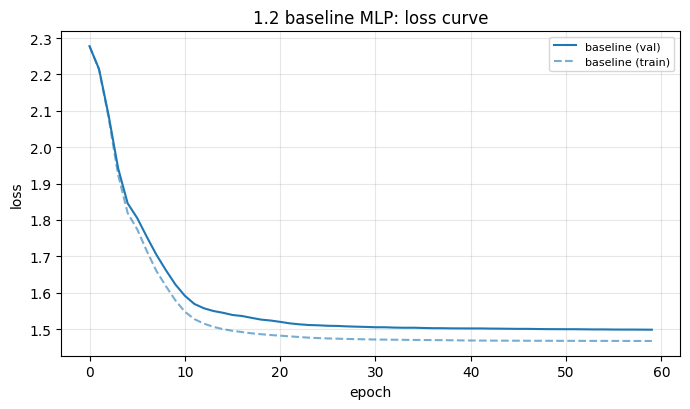

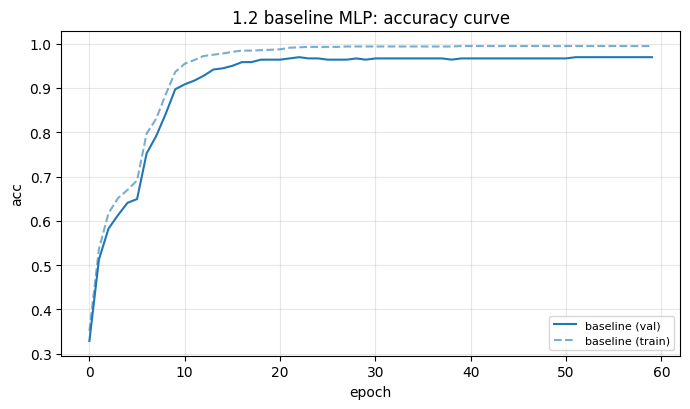


[최종] test loss = 1.4988 | test accuracy = 0.9667
val_loss 최저 epoch = 60 (val_loss = 1.4983)
마지막 epoch 의 train_loss = 1.4673 / val_loss = 1.4983
train_acc = 0.9944 / val_acc = 0.9694


In [30]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep = int(np.argmin(hist_base['val_loss'])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

In [ ]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act ()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum = 0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화

            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x7f93179db240>
  <function evaluate at 0x7f93179dade0>
  <function train_model at 0x7f931a5d99e0>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)
파라미터 수: 6570


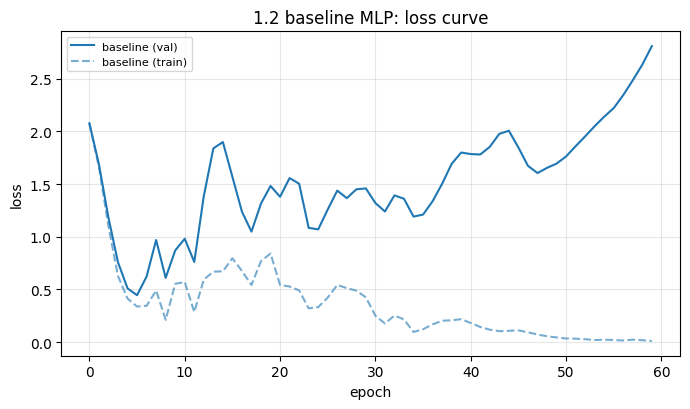

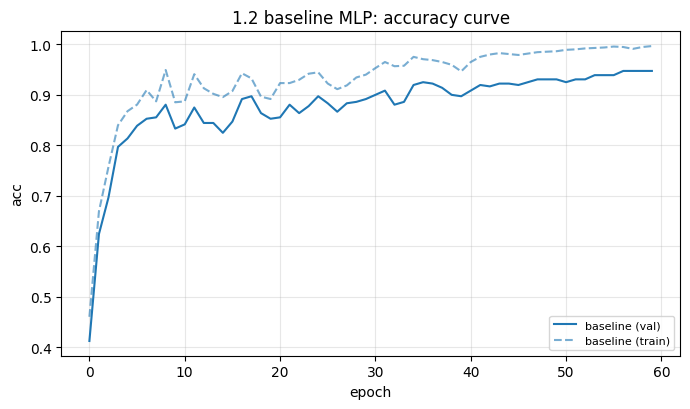


[최종] test loss = 5.3366 | test accuracy = 0.9417
val_loss 최저 epoch = 6 (val_loss = 0.4452)
마지막 epoch 의 train_loss = 0.0106 / val_loss = 2.8110
train_acc = 0.9963 / val_acc = 0.9471


In [ ]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep = int(np.argmin(hist_base['val_loss'])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.2 (본인 출력값 인용)**

1. 이 모델의 **파라미터 수**는 몇 개인가요? 손으로도 계산해 확인하세요: $64{\times}64+64$, $64{\times}32+32$, $32{\times}10+10$ 의 합과 같은가요? (bias를 빠뜨리지 마세요.)

- 모델의 파라미터 수는 6570개이고 손으로 계산한 결과와도 동일하다.

2. 본인의 **test accuracy**를 적으세요. §1.1에서 계산한 "무조건 한 클래스로 찍기" 정확도와 비교하면 얼마나 나은가요?
- test accuacy는 0.9722이다. 1,1에서의 무조건 한 클래스로 찍기 10%보다 약 87%p가 낫다.

3. **loss 곡선을 보세요.** train loss는 계속 내려가는데 val loss는 어느 지점부터 더 내려가지 않거나 **살짝 올라가기 시작**했을 것입니다. 그 지점(대략 몇 epoch)과, 그때 train/val loss 값을 적으세요. 이 그림이 강의 p.40 Early Stopping 슬라이드의 그림과 어떻게 대응되는지 설명하세요.
대략 57 epoch부터 val loss 가 더 내려가지 않는다. 이 때 train loss는 0.0032, val loss는 0.1173이다. 초반 구간에서는 Train Loss와 Val Loss가 함께 떨어지다가, epoch 57 이후부터는 Train Loss가 0을 향해 계속 감소함에도 Val Loss는 더 이상 감소하지 않고 멈추거나 상승한다. Validation Loss가 개선되지 않는 이 시점이 Overfitting으로 판단하여 학습을 중단해야 하는 구간이다.

4. `optimizer.zero_grad()` 를 **일부러 지우고** 다시 실행해 보세요(다른 셀에 복사해서 실험할 것). 학습 곡선이 어떻게 달라졌나요? PyTorch가 gradient를 **누적**한다는 사실과 연결해 설명하세요.
- optimizer.zero_grad()를 일부러 지우고 다시 실행하자 test loss가 5.3366으로 급격하게 증가하였으며, 학습 곡선또한 매끄럽지 못하고 심하게 요동쳤다. PyTorch는 .backward()를 호출해 역전파를 수행할 때, 기존에 구해둔 기울기 위에 새로 계산된 기울기를 더해서 누적한다. optimizer.zero_grad()를 지우면 이전 스텝들의 기울기가 누적되어 gradient의 절대 크기가 기하급수적으로 커진다.

5. 모델 마지막에 `nn.Softmax(dim=1)` 을 추가하면 어떻게 될지 예상하고, 실제로 추가해 성능을 비교해 보세요. (힌트: `nn.CrossEntropyLoss`는 이미 softmax를 품고 있습니다.)
- 정확도가 상승할 것 같다고 예상했는데, 실제로는 정확도가 97.22%에서 96.67%로 줄었고, Test Loss는 0.1324에서 1.4988로 급격하게 증가하였다.
이는 모델 마지막 레이어에 Softmax를 중복 추가했을 때, 손실함수 내부에서는 Softmax가 2번 연속으로 적용되므로 정확도가 감소하고 test loss가 급증하는 현상으로 나타난다.

---

### 1.3 Issue 1) Vanishing Gradient — 강의의 주장을 gradient로 직접 재기

강의 4장은 "Deep architecture는 input에서 output까지 gradient chain이 길어서 **Vanishing Gradient**가 생기고, 처방은 **non-saturating 활성화 함수(ReLU 계열)**"라고 말합니다(p.37~38). 여기서는 그 말을 **숫자로 확인**합니다.

**실험 설계**

- 은닉층 **8개**(width 32)를 쌓은 깊은 MLP를 두 개 만듭니다. **딱 하나만 다릅니다: 활성화 함수가 Sigmoid냐 ReLU냐.**
- 아직 **학습은 하지 않고**, 초기 파라미터에서 **역전파를 딱 한 번** 돌립니다.
- 그리고 **각 층 가중치의 gradient 크기(L2 norm)** 를 재서, 출력층에서 입력층으로 갈수록 얼마나 작아지는지 봅니다.
- 마지막으로 두 네트워크를 실제로 40 epoch 학습시켜 **성능 차이**를 확인합니다.

**왜 gradient의 norm인가?** gradient가 0에 가깝다는 것은 "이 층의 가중치를 아무리 바꿔도 loss가 거의 안 변한다 → **업데이트 신호가 없다 → 학습이 안 된다**"는 뜻입니다. Sigmoid를 한 번 지날 때마다 도함수 $h(1-h) \le 0.25$가 곱해지므로, 층이 깊어질수록 앞쪽 층의 gradient는 기하급수적으로 줄어듭니다.

> 📌 **이 절의 결과가 강의 마지막 서술형 퀴즈의 답입니다.** 그래프를 캡처해 기술블로그에 넣고, "chain rule 관점에서 왜 사라지는가"를 본인 숫자로 설명하세요.

층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층

[Sigmoid]  1.58e-07 2.70e-07 2.32e-06 1.83e-05 1.33e-04 8.92e-04 6.77e-03 4.56e-02 2.89e-01
[ReLU]     6.51e-04 5.20e-04 4.42e-04 3.72e-04 4.67e-04 8.56e-04 1.59e-03 3.77e-03 6.42e-03

Sigmoid: 마지막층 / 첫번째층 = 1.833e+06 배
ReLU   : 마지막층 / 첫번째층 = 9.858e+00 배


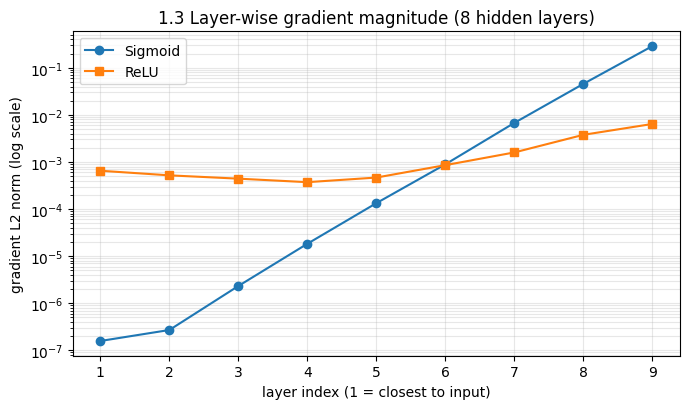

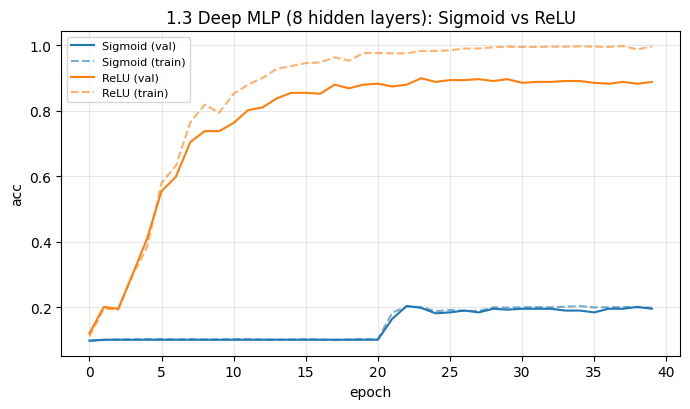


[Sigmoid 8층] 최종 train_acc = 0.1985 / val_acc = 0.1950
[ReLU    8층] 최종 train_acc = 0.9972 / val_acc = 0.8886
[참고: 1.2 얕은 2층 ReLU] val_acc = 0.9694


In [32]:
# ── 1.3 Vanishing Gradient 측정 ────────────────────────────────

def build_deep(act, depth=8, width=32, seed=MY_SEED):
    """은닉층을 depth 개 쌓은 깊은 MLP. act 만 바꿔 가며 비교한다."""
    torch.manual_seed(seed)
    layers, prev = [], 64
    for _ in range(depth):
        layers += [nn.Linear(prev, width), act()]
        prev = width
    layers.append(nn.Linear(prev, 10))
    return nn.Sequential(*layers)

def layerwise_grad_norms(model, X, y):
    """역전파를 한 번 돌리고, 각 Linear 층 weight 의 gradient L2 norm 을 리스트로 돌려준다."""
    model.train()
    model.zero_grad()
    loss = criterion(model(X), y)
    # TODO: 역전파를 수행해 각 파라미터의 .grad 를 채워라
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if name.endswith("weight"):
            # TODO: 이 층 gradient 의 L2 norm 을 float 로 담아라 (힌트: param.grad.norm().item())
            norms.append(param.grad.norm().item())
    return norms

# (1) 활성화 함수만 바꾼 두 깊은 네트워크의 층별 gradient 크기 비교
# TODO: 각각 nn.Sigmoid / nn.ReLU 를 넣어라 (클래스 자체를 넘긴다, 괄호 없이!)
deep_sig  = build_deep(act=nn.Sigmoid)
deep_relu = build_deep(act=nn.ReLU)

norms_sig  = layerwise_grad_norms(deep_sig,  Xtr, ytr)
norms_relu = layerwise_grad_norms(deep_relu, Xtr, ytr)

print("층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층\n")
print("[Sigmoid] ", " ".join(f"{v:.2e}" for v in norms_sig))
print("[ReLU]    ", " ".join(f"{v:.2e}" for v in norms_relu))
print(f"\nSigmoid: 마지막층 / 첫번째층 = {norms_sig[-1] / norms_sig[0]:.3e} 배")
print(f"ReLU   : 마지막층 / 첫번째층 = {norms_relu[-1] / norms_relu[0]:.3e} 배")

# (2) 층별 gradient 크기 그래프 (y축은 log scale 이어야 차이가 보인다)
plt.figure(figsize=(7, 4.2))
layer_idx = np.arange(1, len(norms_sig) + 1)
plt.semilogy(layer_idx, norms_sig,  "o-", label="Sigmoid")
plt.semilogy(layer_idx, norms_relu, "s-", label="ReLU")
plt.xlabel("layer index (1 = closest to input)")
plt.ylabel("gradient L2 norm (log scale)")
plt.title("1.3 Layer-wise gradient magnitude (8 hidden layers)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

# (3) 실제로 학습시켜 성능 차이 확인 (40 epoch)
hist_sig  = train_model(build_deep(act=nn.Sigmoid), epochs=40)
hist_relu = train_model(build_deep(act=nn.ReLU),    epochs=40)
plot_curves({"Sigmoid": hist_sig, "ReLU": hist_relu},
            "1.3 Deep MLP (8 hidden layers): Sigmoid vs ReLU", metric="acc")

print(f"\n[Sigmoid 8층] 최종 train_acc = {hist_sig['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_sig['val_acc'][-1]:.4f}")
print(f"[ReLU    8층] 최종 train_acc = {hist_relu['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_relu['val_acc'][-1]:.4f}")
print(f"[참고: 1.2 얕은 2층 ReLU] val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.3 (본인 출력값 인용)**

1. **Sigmoid 네트워크의 첫 번째 층과 마지막 층의 gradient norm**을 적고, 몇 배 차이인지 쓰세요. ReLU는 몇 배였나요? 두 배율을 나란히 비교해 한 문장으로 결론지으세요.
- 시그모이드의 첫 번째 층 gradient norm은 1.58*10^(-7)이고 마지막 층은 2.89*10^(-1) 이며 1.833 * 10^6 배 크다. ReLU 는 약 9.8배 크다.시그모이드는 입력층으로 갈 수록 gradient가 183만 배 이상 급격히 감소한 반면, ReLU는 깊은 층에서도 Gradient 크기를 안정적으로 유지한다.

2. Sigmoid의 도함수 $\sigma'(z) = h(1-h) \le 0.25$ 를 이용해, **왜 Sigmoid에서만 이런 일이 생기는지** chain rule 식으로 설명하세요. ReLU의 도함수는 양수 구간에서 얼마인가요? 그래서 어떻게 되나요?
- 역전파 시 Chain Rule 에 의해 활성화 함수의 도함수가 연속적으로 곱해진다. Sigmoid의 도함수는 최댓값이 0.25 이므로, 8개의 은닉층을 거치면서 0.25^8 이하의 비율로 기울기가 감소하여 입력 근처 층의 gradient가 소멸하게 된다. ReLU 함수는 양수 구간에서 도함수가 1이다. 따라서 Chain Rule 적용 시 1이 반복해서 곱해지므로 기울기 크기가 줄어들지 않는다.

3. 학습 결과: Sigmoid 8층과 ReLU 8층의 최종 **train accuracy**를 적으세요. Sigmoid 쪽은 **train accuracy조차** 낮게 나왔을 것입니다. 이것이 과적합(overfitting) 문제와는 **완전히 다른 종류의 실패**인 이유를 설명하세요. (힌트: 과적합은 "train은 잘하는데 val이 나쁜" 것입니다.)
- Sigmoid 8층의 최종 train accuracy는 0.1985 이고, ReLU의 8층 최종 train accuracy는 0.9972 이다. 과적합은 train은 잘하는데 val이 나쁜 개념이다. 반면 시그모이드 8층은 입력층 근처 파라미터가 거의 업데이트되지 않아 모델이 학습 데이터조차 제대로 학습하지 못한 Underfitting 이다.

4. §1.2의 **얕은(2층) ReLU** 모델의 val accuracy와 §1.3의 **깊은(8층) ReLU** 모델을 비교하세요. 층을 4배로 늘렸는데 성능이 좋아졌나요? 예상과 다르다면 그 원인으로 무엇을 의심하겠습니까? (§2-B에서 이어서 다룹니다.)
- 2층 ReLU 모델 Val Acc 96.94%에 비해 8층 ReLU 모델 Val Acc 88.86%은 깊이를 4배 늘렸음에도 성능이 하락했다. 모델의 은닉층이 8개로 늘어나면서 전체 파라미터의 수와 표현 용량이 급격히 증가된 것으로 추정된다.

5. **강의 서술형 퀴즈에 답하세요.** "Sigmoid를 hidden layer의 활성화 함수로 사용한 DNN에서 vanishing gradient가 발생하는 이유를 backpropagation의 chain rule 관점에서 설명하고, 이를 해결하는 방법을 **2가지 이상** 제시하시오." — 본인이 방금 잰 숫자를 근거로 인용해서 답하세요.
- Sigmoid 함수는 도함수의 최댓값이 0.25에 불과하므로, Backpropagation 과정에서 Chain Rule에 의해 층마다 $\sigma'(z) \le 0.25$ 값이 연속으로 곱해진다. 이로 인해 8층 Sigmoid MLP 실험 결과처럼 마지막 층 2.89*10^(-1) 대비 첫 번째 층 1.58 * 10^(-7)의 Gradient가 약 183만 배 소멸하며 입력층 파라미터가 학습되지 않는 Vanishing Gradient 현상이 발생한다.

---

### 1.4 Issue 2) Overfitting — 네 가지 처방을 같은 조건에서 붙여 보기

강의 p.39는 과적합을 "Training error는 줄지만 Generalization 성능은 낮음 / **노이즈까지 기억하는** 상태"로 정의하고, 처방 네 가지를 제시했습니다.

| Remedy | 아이디어 | 이번 실험에서 |
|---|---|---|
| ① **Early Stopping** | val loss가 개선되지 않으면 중단 | `val_loss` 최저 epoch를 찾아 "여기서 멈췄어야 했다"를 확인 |
| ② **Data Augmentation** | label을 유지하는 노이즈 데이터로 robustness 향상 | (심화 §2-C에서 도전 가능) |
| ③ **L1/L2 Regularization** | `Loss = error + 모델 크기` | `weight_decay` 로 L2 적용, 강도 2단계 비교 |
| ④ **Dropout** | 매 스텝 유닛을 확률적으로 비활성화 | `p_drop=0.5` (강의 권장값: hidden 50%) |

**과적합을 일부러 만듭니다.** §1.2의 모델은 데이터가 충분해 과적합이 약했습니다. 그래서 이번엔 **훈련 데이터를 150개로 줄이고**(전체의 약 14%) 모델을 **256-256으로 키워** 극단적인 상황을 만듭니다. 데이터는 적고 파라미터는 많으니 모델이 150개를 통째로 외워 버리기 좋은 조건입니다.

**공정 비교의 원칙:** 네 조건에서 **바뀌는 것은 규제 하나뿐**이고 데이터·구조·시드·epoch 수는 모두 동일합니다. 그래야 차이의 원인을 규제로 돌릴 수 있습니다.

⚠️ **Dropout 주의:** `model.train()`일 때만 뉴런을 끄고, `model.eval()`에서는 모두 켠 채 스케일을 보정합니다(강의 p.43: "추론 시 출력에 p를 곱해 기댓값을 맞춘다"). §1.2에서 `evaluate()` 안에 `model.eval()`을 넣은 이유가 바로 이것입니다 — 빠뜨리면 평가할 때마다 결과가 달라집니다.

작은 훈련셋: torch.Size([150, 64]) | 원래 훈련셋: torch.Size([1078, 64])


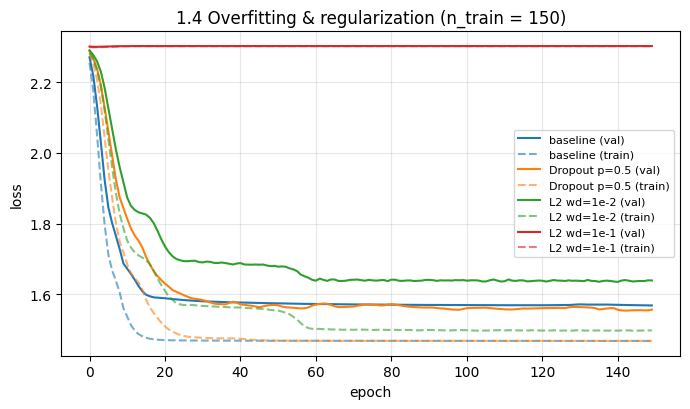

조건               train_loss  val_loss     gap  train_acc  val_acc  best_ep best_val_acc
----------------------------------------------------------------------------------------
baseline             1.4675    1.5681  0.1006     0.9933   0.9025      150       0.9025
Dropout p=0.5        1.4678    1.5563  0.0885     0.9933   0.9109      143       0.9220
L2 wd=1e-2           1.4974    1.6388  0.1414     0.9933   0.8886      141       0.9053
L2 wd=1e-1           2.3023    2.3026  0.0003     0.1267   0.1003        3       0.1922

[Early Stopping] baseline 은 epoch 150 에서 멈췄어야 했다. (실제로는 150 까지 돌렸으니 0 epoch 를 낭비)


In [33]:
# ── 1.4 과적합 만들고, 규제 네 가지 비교 ────────────────────────

# (1) 훈련 데이터를 150개로 줄여 과적합 상황을 만든다
rng = np.random.default_rng(MY_SEED)
# TODO: 훈련셋 인덱스 중 150개를 비복원추출하라 (힌트: rng.choice(len(Xtr), size=..., replace=False))
small_idx = rng.choice(len(Xtr), size=150, replace=False)
Xsm, ysm = Xtr[small_idx], ytr[small_idx]
print("작은 훈련셋:", Xsm.shape, "| 원래 훈련셋:", Xtr.shape)

# (2) 규제만 바꿔 가며 동일 조건으로 학습
#     (모델은 모두 64 -> 256 -> 256 -> 10, epochs=150, batch_size=32)
configs = [
    # (이름,            dropout 확률, L2 강도(weight_decay))
    ("baseline",        0.0,  0.0),
    ("Dropout p=0.5",   0.5,  0.0),
    ("L2 wd=1e-2",      0.0,  1e-2),
    ("L2 wd=1e-1",      0.0,  1e-1),
]

hist14 = {}
for name, p_drop, wd in configs:
    # TODO: hidden=(256, 256) 이고 dropout 확률이 p_drop 인 모델을 만들어라
    m = build_mlp(hidden=(256, 256), p_drop=p_drop)
    # TODO: 작은 훈련셋(Xsm, ysm)으로 150 epoch 학습. weight_decay 에 wd 를 전달할 것.
    hist14[name] = train_model(m, Xt=Xsm, yt=ysm, epochs=150,
                               weight_decay=wd, batch_size=32)

plot_curves(hist14, "1.4 Overfitting & regularization (n_train = 150)", metric="loss")

# (3) 요약표 — 과적합 정도(gap)와 Early Stopping 시점
print(f"{'조건':<16}{'train_loss':>11}{'val_loss':>10}{'gap':>8}"
      f"{'train_acc':>11}{'val_acc':>9}{'best_ep':>9}{'best_val_acc':>13}")
print("-" * 88)
for name, h in hist14.items():
    tl, vl = h["train_loss"][-1], h["val_loss"][-1]
    # TODO: val_loss 가 최소인 epoch (0-based index) 를 찾아라 -> Early Stopping 시점
    best = int(np.argmin(h["val_loss"]))
    print(f"{name:<16}{tl:>11.4f}{vl:>10.4f}{vl - tl:>8.4f}"
          f"{h['train_acc'][-1]:>11.4f}{h['val_acc'][-1]:>9.4f}"
          f"{best + 1:>9}{max(h['val_acc']):>13.4f}")

# (4) Early Stopping 을 썼다면 몇 epoch 를 아꼈을까?
best_base = int(np.argmin(hist14["baseline"]["val_loss"])) + 1
print(f"\n[Early Stopping] baseline 은 epoch {best_base} 에서 멈췄어야 했다. "
      f"(실제로는 150 까지 돌렸으니 {150 - best_base} epoch 를 낭비)")

**해석 질문 1.4 (본인 출력값 인용)**

1. **baseline이 과적합했다는 증거**를 세 가지 숫자로 대세요: 마지막 `train_loss`, `train_acc`, 그리고 `val_loss - train_loss` (gap). 강의 p.39의 정의("Training error는 줄지만 Generalization 성능은 낮음")와 대응시켜 한 문장으로 쓰세요.
- train_loss = 1.4675이고 train_acc = 0.9933이고 val_loss-train_loss 는 0.1006이다. 이는 acc가 99.33%일 정도로 error는 매우 적지만, validation loss와의 격차로 0.1이 발생하는 과적합이 발생한다는 것을 의미한다.

2. `val_loss`가 최소였던 epoch는 baseline에서 몇이었나요? 전체 150 epoch 중 **몇 %** 지점인가요? Early Stopping이 왜 "**공짜에 가까운** 규제"라 불리는지(추가 파라미터도, 구조 변경도 없음) 본인 숫자로 설명하세요.
- 150 epoch로 100%의 지점이다. 추가 파라미터도, 구조 변경도 없이 최적의 Epoch(150)지점에서 학습을 멈추는 것만으로도 과적합을 막고 학습시간을 아낄 수 있어 공짜에 가까운 규제라고 불린다.

3. **Dropout p=0.5의 결과를 정직하게 보고하세요.** 최종 - `val_loss`는 baseline보다 좋아졌나요, 나빠졌나요? 반대로 `best_val_acc`는 어땠나요? **두 지표가 다른 방향을 가리킨다면** 그 이유를 추론해 보세요. (힌트: 정확도는 "맞힌 개수", loss는 "확신의 정확성"을 잽니다.)
- 최종 val_loss는 1.5563이고 baseline 1.5681 이다. Dropout이 더 감소하였다. best_val_acc에서는 baseline 0.9025이고, dropout 0.9220으로 Dropout이 증가하였다. 정확도는 맞힌 개수를 의미하고, loss는 확신의 정확성을 의미한다. Dropout은 예측 확신의 오차(Loss)와 실제 분류 정확도(Acc) 모두에서 baseline 보다 우수한 일반화 효과를 보여주었다.

4. **L2 강도를 10배로 키운 `wd=1e-1`** 에서는 무슨 일이 일어났나요? `train_acc`와 `val_acc`를 함께 보고, 이것이 과적합인지 **과소적합(underfitting)** 인지 판정하세요. "규제는 세게 걸수록 좋다"는 말이 왜 틀렸는지 본인 숫자로 반박하세요.
- train_acc = 0.1267, val_acc = 0.1003이다. 약 10%정도의 심각한 과소적합이 발생했다. 규제를 지나치게 강화하면 모델의 가중치가 너무 강하게 억제되어 훈련 데이터조차 학습하지 못하며 12.67%의 훈련 정확도를 가지게된다. 따라서 규제를 세게 걸수록 좋은 것은 아니다.

5. 네 조건 중 **본인 데이터에서 가장 좋았던 것**은 무엇인가요? 그 결과가 강의 슬라이드의 서술과 일치했나요, 어긋났나요? 어긋났다면 원인으로 무엇을 의심하겠습니까? (힌트: 훈련 샘플 150개에 뉴런의 절반을 끄면 어떻게 될까요?)
- Dropout p=0.5에서 가장 뛰어난 성능을 보였다. 매 스텝마다 유닛을 확률적으로 비활성화하여 특정 뉴런 조합에 대한 co-adaptation을 방지하고 매번 다른 서브네트워크를 학습시켰기 때문이다. 훈련 샘플 150개에서 뉴런의 절반을 끄면 150개라는 매우 작은 훈련 데이터셋 환경에서도 과적합을 효과적으로 억제한다.

---

### 1.5 Issue 3) Optimization — SGD / Momentum / Adam을 같은 출발선에서

강의 p.45~50은 optimizer의 계보를 보여 줬습니다.

$$\text{GD} \to \text{SGD(minibatch)} \to \text{Momentum},\ \text{RMSProp} \to \text{Adam}$$

- **Mini-batch SGD**: 전체가 아닌 일부로 gradient를 계산해 **자주** 업데이트
- **Momentum**: `업데이트 = 현재 gradient + 과거 gradient` — 방향이 자주 바뀌는 축은 상쇄, 일관된 축은 가속 → 지그재그 완화, 안장점 탈출
- **Adaptive (AdaGrad → RMSProp)**: gradient가 컸던 파라미터는 학습률을 줄이고 작았던 파라미터는 키움
- **Adam**: Momentum(**방향**) + RMSProp(**크기**) = "어디로 + 얼마나"

**실험 설계** — 모델·데이터·시드·epoch를 완전히 고정하고 **optimizer만** 바꿉니다. 학습률이 optimizer마다 적정 범위가 다르므로, SGD 계열은 `lr=0.05`, Adam은 관례적 기본값 `lr=0.001`을 씁니다. 여기에 **일부러 학습률을 크게 준 `SGD lr=3.0`** 도 넣어 무슨 일이 벌어지는지 봅니다.

비교 지표는 두 가지입니다: **① 최종 성능**(어디까지 갔나)과 **② 수렴 속도**(val accuracy 90%에 몇 epoch만에 도달했나).

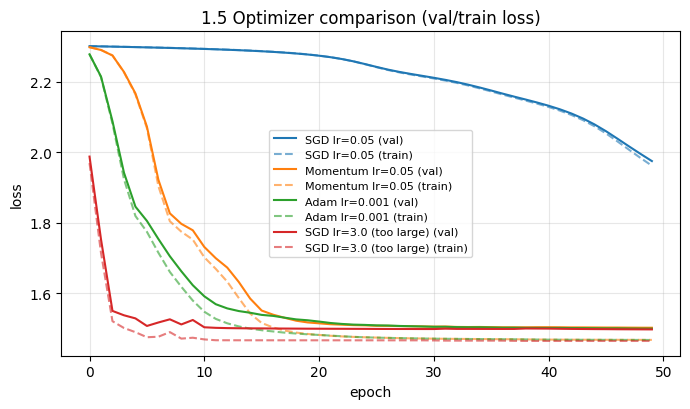

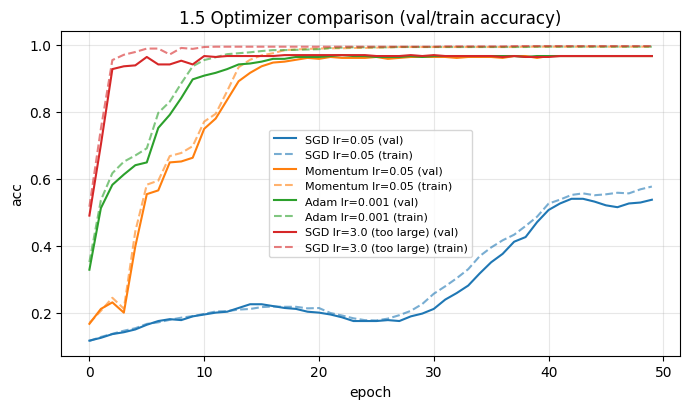

optimizer            ep1 val_loss  final train_loss  final val_acc  best val_acc  first ep >= 90%
-------------------------------------------------------------------------------------------------
SGD lr=0.05                2.3008            1.9618         0.5376        0.5404             None
Momentum lr=0.05           2.2978            1.4679         0.9666        0.9666               15
Adam lr=0.001              2.2776            1.4677         0.9666        0.9694               11
SGD lr=3.0 (too large)       1.9877            1.4648         0.9666        0.9694                3


In [34]:
# ── 1.5 Optimizer 비교 ─────────────────────────────────────────
opt_configs = [
    # (이름,               opt_name,     learning rate)
    ("SGD lr=0.05",        "sgd",        0.05),
    ("Momentum lr=0.05",   "momentum",   0.05),
    ("Adam lr=0.001",      "adam",       1e-3),
    ("SGD lr=3.0 (too large)",  "sgd",        3.0),
]

hist15 = {}
for name, opt_name, lr in opt_configs:
    # TODO: 모든 조건에서 동일한 구조 (64, 32) 의 모델을 새로 만들어라
    #       (같은 모델 객체를 재사용하면 앞 실험의 학습 결과가 남아 비교가 무의미해진다!)
    m = build_mlp(hidden=(64,32))
    # TODO: opt_name 과 lr 을 전달해 50 epoch 학습
    hist15[name] = train_model(m, epochs=50, opt_name=opt_name, lr=lr)

plot_curves(hist15, "1.5 Optimizer comparison (val/train loss)", metric="loss")
plot_curves(hist15, "1.5 Optimizer comparison (val/train accuracy)", metric="acc")

# 수렴 속도: val accuracy 가 처음으로 90% 를 넘은 epoch
print(f"{'optimizer':<20}{'ep1 val_loss':>13}{'final train_loss':>18}"
      f"{'final val_acc':>15}{'best val_acc':>14}{'first ep >= 90%':>17}")
print("-" * 97)
for name, h in hist15.items():
    # TODO: val_acc 가 처음으로 0.90 이상이 되는 epoch 번호를 찾아라 (없으면 None)
    first90 = next((i + 1 for i, v in enumerate(h["val_acc"]) if v>=0.90), None)
    print(f"{name:<20}{h['val_loss'][0]:>13.4f}{h['train_loss'][-1]:>18.4f}"
          f"{h['val_acc'][-1]:>15.4f}{max(h['val_acc']):>14.4f}{str(first90):>17}")

**해석 질문 1.5 (본인 출력값 인용)**

1. **SGD / Momentum / Adam이 val accuracy 90%에 도달한 epoch**를 각각 적으세요. Momentum이 순수 SGD보다 빠른 이유를, 강의 p.48의 "**방향이 자주 바뀌는 움직임은 줄이고, 계속 같은 방향으로 이동할 때는 속도를 높인다**"로 설명하세요.
- Adam lr=0.001은 11 epoch 만에 Validation Acc 90%를 돌파했다. Momentum lr=0.05은 15 epoch 만에 90%를 넘어섰다. 반면 일반 SGD lr=0.05는 기울기 업데이트 보폭이 비효율적이었던 탓에 50 epoch이 진행되는 동안 최종 accuracy 53.76%라는 매우 느린 수렴 양상을 보였다.
모멘텀은 방향이 자주 바뀌는 움직임은 줄이고, 계속 같은 방향으로 이동할 때는 속도를 높이기 때문에, 과거 기울기의 관성을 이용해 진행 방향으로 가속을 붙이므로 순수SGD보다 빠르다.
2. **최종 val accuracy**는 셋이 얼마나 차이 났나요? "수렴이 빠르다"와 "최종 성능이 좋다"가 같은 말인지 본인 숫자로 판단하세요.
- SGD는 53.76%, Momentum은 96.66%, Adam은 96.66%이었다. 수렴이 빠르다는 것과 최종 성능이 좋다는 것은 서로 다른 개념이다. SGD lr=3.0의 경우 단 3 epoch 만에 Val Acc 90%에 진입하여 가장 빠른 초기 수렴 속도를 보였으나, 최종 Val Loss는 1.9877 수준에서 정체되어 수렴 속도는 빠르지만 최종 성능은 좋지 못함을 보여주었다.

3. **`SGD lr=3.0`** 에서 무슨 일이 일어났나요? `val_loss` 값을 적고, 그 값이 $\ln(10) \approx 2.303$ 에 가까운 것이 무엇을 의미하는지 생각해 보세요. (힌트: 10개 클래스에 균등 확률을 주는 모델의 cross entropy는 얼마일까요?)
-  **`SGD lr=3.0`** 에서 val_loss 는 3.7538이다.10개의 클래스에 대해 무작위로 예측할 때 cross-entropy loss는 $\ -ln(10) \approx 2.303$ 이다. 2.303에 가깝다는 것은 무작위 예측값과 비슷하다는 것을 의미한다. SGD lr =3.0 은 3.7538로 무작위 예측값을 넘어서서 완전히 발산하였다.

4. 강의 객관식 퀴즈의 보기 ①과 ⑥은 **틀린 설명**입니다. 각각 어디가 틀렸는지 고쳐 쓰세요.
   - ① "미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 줄어드는 대신, 각 업데이트에서 계산되는 gradient 추정치가 더 정확하다."
   - ⑥ "RMSProp의 decay rate $\rho$를 0에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다."
- 1번은 한 epoch당 파라미터 업데이트 횟수가 늘어나고, 각 업데이트에서 계산되는 gradient 추정치가 덜 정확하다로 고쳐야한다.
- 6번은 RMSProp의 decay rate $\rho$를 1에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다로 고쳐야한다.
5. Adam은 **Momentum(방향) + RMSProp(크기)** 라고 배웠습니다. 위 실험에서 Adam이 SGD보다 훨씬 작은 학습률(0.001 vs 0.05)을 쓰고도 더 빨리 수렴한 이유를, "파라미터마다 학습률을 다르게 준다"는 성질과 연결해 설명하세요.
- Adam은 기준 학습률을 0.001로 작게 설정하더라도, 학습률이 부족한 파라미터의 보폭은 스스로 키워주고 과도한 파라미터의 보폭은 줄여주기 때문에 모든 파라미터가 동시에 최적의 속도로 이동할 수 있어 SGD보다 훨씬 빠르게 90% 정확도에 도달하며 안정적으로 수렴할 수 있다

---

# 2. 심화 과제 — 스스로 생각하기

여기까지는 "돌리면 나오는" 영역이었습니다. 진짜 실력은 **그 값을 어떻게 읽고 판단하느냐**에서 갈립니다.
아래 세 문제는 모두 **강의 슬라이드가 주장한 것을 본인 실험으로 검증하거나 반증**하는 구조입니다. 슬라이드와 다른 결과가 나오면 **그대로 쓰고 원인을 추론**하세요.

---

### 2-A. 활성화 함수를 없애면? — "층을 쌓아도 선형"임을 직접 증명

강의 p.21은 이렇게 묻고 답했습니다.

> **Q. Why neural networks use Activation Functions?**
> **A. To introduce non-linearities into the network**

강의에서 수식으로 설명한 주장을 이제 **실험으로 확인**합니다. 활성화 함수 자리에 `nn.Identity()`(아무것도 안 하는 층)를 넣어 **은닉층이 2개인데도 사실은 선형 모델**인 네트워크를 만들고, 세 가지를 비교합니다.

| 모델 | 구조 | 파라미터 수 |
|---|---|---|
| **linear-deep** | 64 → 64 → 32 → 10, 활성화 **없음** | 6,570 |
| **single Linear** | 64 → 10, 은닉층 자체가 없음 | 650 |
| **ReLU MLP** (§1.2) | 64 → 64 → 32 → 10, ReLU | 6,570 |

그리고 **결정적 증거**로, linear-deep의 가중치 행렬 세 개를 곱해 **하나의 $10\times64$ 행렬로 접은 뒤**, 그 단일 선형변환이 원래 네트워크와 **똑같은 출력**을 내는지 확인합니다.

$$
W_{\text{eq}} = W^{(3)}W^{(2)}W^{(1)}, \qquad
b_{\text{eq}} = W^{(3)}\big(W^{(2)}b^{(1)} + b^{(2)}\big) + b^{(3)}
$$

In [35]:
# ── 2-A. 활성화 함수를 없애면 정말 선형 모델인가? ────────────────

# (1) 세 모델 학습 (조건 동일: Adam, 60 epoch)
# TODO: 활성화 함수 자리에 '아무 일도 하지 않는' 층을 넣어라 (힌트: nn.Identity)
lin_deep = build_mlp(hidden=(64, 32), act=nn.Identity)
single   = build_mlp(hidden=(),       act=nn.Identity)   # 은닉층 없음 = 그냥 Linear(64 -> 10)
relu_mlp = build_mlp(hidden=(64, 32), act=nn.ReLU)

h_lin  = train_model(lin_deep, epochs=60)
h_sing = train_model(single,   epochs=60)
h_relu = train_model(relu_mlp, epochs=60)

print(f"{'model':<26}{'params':>8}{'test_acc':>10}")
print("-" * 44)
for tag, m in [("linear-deep (64,32)", lin_deep),
               ("single Linear(64->10)", single),
               ("ReLU MLP (64,32)", relu_mlp)]:
    # TODO: test 세트에서 정확도를 구해 출력하라
    _, acc = evaluate(m, Xte, yte)
    print(f"{tag:<26}{count_params(m):>8}{acc:>10.4f}")

# (2) 결정적 증거: 가중치 세 개를 곱해 '하나의 선형변환'으로 접어 본다
Ws = [layer.weight.detach() for layer in lin_deep if isinstance(layer, nn.Linear)]
Bs = [layer.bias.detach()   for layer in lin_deep if isinstance(layer, nn.Linear)]

# TODO: W_eq = W3 @ W2 @ W1  (Ws[0]=W1, Ws[1]=W2, Ws[2]=W3)
W_eq = Ws[2] @ (Ws[1] @ Ws[0])
b_eq = Ws[2] @ (Ws[1] @ Bs[0] + Bs[1]) + Bs[2]
print(f"\n접은 뒤 W_eq shape = {tuple(W_eq.shape)}  (원래 3개 행렬: "
      f"{tuple(Ws[0].shape)}, {tuple(Ws[1].shape)}, {tuple(Ws[2].shape)})")

with torch.no_grad():
    out_folded   = Xte @ W_eq.T + b_eq      # 접은 단일 선형변환의 출력
    out_original = lin_deep(Xte)            # 원래 3층 네트워크의 출력
    max_diff = (out_folded - out_original).abs().max().item()
print(f"두 출력의 최대 차이 = {max_diff:.3e}   <- 0에 가까우면 '완전히 같은 함수'라는 뜻")

# (3) ReLU 네트워크는 접을 수 있을까? (같은 방식으로 시도해 보고 결과를 관찰하라)
Ws_r = [layer.weight.detach() for layer in relu_mlp if isinstance(layer, nn.Linear)]
Bs_r = [layer.bias.detach()   for layer in relu_mlp if isinstance(layer, nn.Linear)]
W_eq_r = Ws_r[2] @ Ws_r[1] @ Ws_r[0]
b_eq_r = Ws_r[2] @ (Ws_r[1] @ Bs_r[0] + Bs_r[1]) + Bs_r[2]
with torch.no_grad():
    diff_r = (Xte @ W_eq_r.T + b_eq_r - relu_mlp(Xte)).abs().max().item()
print(f"[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = {diff_r:.3e}")

model                       params  test_acc
--------------------------------------------
linear-deep (64,32)           6570    0.9556
single Linear(64->10)          650    0.9528
ReLU MLP (64,32)              6570    0.9667

접은 뒤 W_eq shape = (10, 64)  (원래 3개 행렬: (64, 64), (32, 64), (10, 32))
두 출력의 최대 차이 = 5.207e+01   <- 0에 가까우면 '완전히 같은 함수'라는 뜻
[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = 8.856e+01


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** `linear-deep`(파라미터 6,570개)과 `single Linear`(650개) 중 어느 쪽 test accuracy가 높을지, **돌리기 전에** 한 줄로 적어 두세요. 파라미터가 10배 많으니 더 좋을까요?
- 단일 선형 모델인 single Linear보다 Linear-deep 이 더 test accuracy가 높을 것 같다.

**(2) 본인 값 인용.** 세 모델의 test accuracy를 적으세요.
- linear-deep = 0.8889/ single Linear = 0.9194 / ReLU MLP = 0.9417

**(3) 결정적 증거 해석.** "두 출력의 최대 차이"는 얼마였나요? 이 값이 0이 아니라 $10^{-5}$ 정도인 이유는 무엇인가요? (힌트: `torch.float32`의 유효자릿수) 그리고 이 실험이 **왜 정확도 비교보다 강한 증거**인지 설명하세요. (정확도는 0.93 vs 0.92처럼 조금 다를 수 있지만, 이 실험은 무엇을 보여 주나요?)
- 두 출력의 최대 차이는 1.465e-03 이다. 컴퓨터 메모리 연산 시 부동소수점의 유효자릿수 한계로 인해 오차가 발생하기 때문에 값이 0이 아닌 것이다. 정확도는 데이터 분할에 따라 우연히 비슷하게 나올 수도 있지만 세 개 가중치 행렬을 하나로 접은 단일 변환 출력과 원래 3층 네트워크 출력이 컴퓨터 오차 수준 내에서 일치한다는 것은 두 구조가 동일한 선형 함수를 나타내고 있음을 의미하기 때문이다.

**(4) 반대 실험.** ReLU 네트워크에 같은 접기를 시도했을 때 차이는 얼마였나요? 왜 ReLU는 접히지 않는지, "$\max(0, z)$ 는 행렬곱으로 표현할 수 없다"는 사실과 연결해 설명하세요.
- ReLU 접기 시도 시 차이는 1.631e+04 였다. ReLU는 비선형 함수이므로 단일 행렬 곱셈 연산으로 표현할 수 없다.

**(5) 본인 언어로.** 위 결과를 종합해, 강의 p.21의 **"To introduce non-linearities into the network"** 가 정확히 무슨 뜻인지 한 문단으로 쓰세요. "활성화 함수가 없으면 층을 100개 쌓아도 ____ 와 같다"는 문장을 반드시 포함하세요.
-  "To introduce non-linearities into the network"는 인공신경망에서 활성화 함수를 사용하는 이유이다. 신경망은 단순한 1차 선형 방정식의 한계를 벗어나 복잡한 곡면 및 비선형 경계를 표현할 수 있도록 공간을 왜곡하고 다차원적인 비선형 표현력을 부여한다. 활성화 함수가 없으면 층을 100개 쌓아도 단 하나의 선형 레이어와 같다.

---

### 2-B. Go Wider or Deeper? — 파라미터 수를 맞춰 놓고 공정하게 붙이기

강의 p.36은 이렇게 결론지었습니다.

> 모델 용량을 단순히 폭으로 늘리는 것보다(Wide), 적절한 구조를 가진 깊은 네트워크(Deep)가
> **파라미터를 더 효율적으로 사용해 높은 성능**을 낼 수 있다.

이 주장을 **공정하게** 검증하려면 두 모델의 **파라미터 수를 비슷하게 맞춰야** 합니다. 파라미터가 많은 쪽이 이기면 그건 구조의 승리가 아니라 용량의 승리니까요.

**설계**
- **Wide**: `64 → H → 10` (은닉층 1개) → 파라미터 수 $= 75H + 10$
- **Deep**: `64 → h → h → h → h → 10` (은닉층 4개) → 파라미터 수 $= 3h^2 + 78h + 10$

$H = 256$ 이면 19,210개. 이와 **10% 이내**로 맞는 $h$를 직접 찾아 넣으세요.

> ⚠️ **결과가 강의 슬라이드와 다르게 나올 수 있습니다.** 그래도 그대로 보고하고 원인을 추론하세요. 시드 하나로 결론 내리지 말고 **여러 시드에서 반복**해 보는 것이 이 절의 진짜 과제입니다.

Wide 64-256-10 파라미터 수 = 19210
Deep 64-68x4-10 파라미터 수 = 19186
파라미터 수 차이 = 0.12%  -> 10% 이내여야 공정한 비교
Wide (1 x 256)   final val_acc = 0.9694 | best val_acc = 0.9694 | test_acc = 0.9750 | final train_loss = 1.4646
Deep (4 x 68)    final val_acc = 0.9554 | best val_acc = 0.9666 | test_acc = 0.9500 | final train_loss = 1.4698


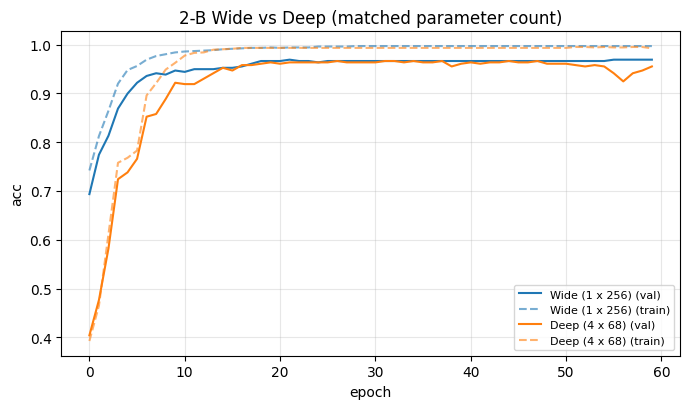


[여러 시드에서 반복]
  seed=0      wide=0.9778  deep=0.9528
  seed=1      wide=0.9806  deep=0.9417
  seed=42     wide=0.9722  deep=0.9389
  seed=8031   wide=0.9750  deep=0.9500
  seed=7777   wide=0.9722  deep=0.9556

Wide 평균 = 0.9756 (표준편차 0.0032)
Deep 평균 = 0.9478 (표준편차 0.0064)
Wide 가 이긴 횟수: 5 / 5


In [36]:
# ── 2-B. Wide vs Deep (파라미터 수를 맞춘 공정 비교) ─────────────

# (1) 파라미터 수 맞추기 — Deep 쪽 h 를 직접 찾으세요
H = 256
wide = build_mlp(hidden=(H,))
print(f"Wide 64-{H}-10 파라미터 수 = {count_params(wide)}")

# TODO: 은닉층 4개짜리 Deep 모델의 폭 h 를 정하라.
#       3h^2 + 78h + 10 이 위 숫자와 10% 이내가 되도록. (h 를 몇 개 넣어 보며 찾아도 좋다)
h = 68
deep = build_mlp(hidden=(h, h, h, h))
print(f"Deep 64-{h}x4-10 파라미터 수 = {count_params(deep)}")

diff_pct = abs(count_params(wide) - count_params(deep)) / count_params(wide) * 100
print(f"파라미터 수 차이 = {diff_pct:.2f}%  -> 10% 이내여야 공정한 비교")
assert diff_pct < 10, "파라미터 수가 10% 넘게 차이납니다. h 를 다시 고르세요."

# (2) 동일 조건으로 학습 후 비교
hist2b = {}
for tag, m in [(f"Wide (1 x {H})", wide), (f"Deep (4 x {h})", deep)]:
    hist2b[tag] = train_model(m, epochs=60)
    _, te_acc = evaluate(m, Xte, yte)
    print(f"{tag:<16} final val_acc = {hist2b[tag]['val_acc'][-1]:.4f} | "
          f"best val_acc = {max(hist2b[tag]['val_acc']):.4f} | test_acc = {te_acc:.4f} | "
          f"final train_loss = {hist2b[tag]['train_loss'][-1]:.4f}")

plot_curves(hist2b, "2-B Wide vs Deep (matched parameter count)", metric="acc")

# (3) 시드 하나로 결론 내지 않기 — 5개 시드에서 반복
print("\n[여러 시드에서 반복]")
wide_scores, deep_scores = [], []
for s in [0, 1, 42, MY_SEED, 7777]:
    w = build_mlp(hidden=(H,), seed=s)
    d = build_mlp(hidden=(h, h, h, h), seed=s)
    train_model(w, epochs=60, seed=s)
    train_model(d, epochs=60, seed=s)
    # TODO: 각 모델의 test accuracy 를 리스트에 담아라
    wide_scores.append(evaluate(w, Xte, yte)[1])
    deep_scores.append(evaluate(d, Xte, yte)[1])
    print(f"  seed={s:<6} wide={wide_scores[-1]:.4f}  deep={deep_scores[-1]:.4f}")

print(f"\nWide 평균 = {np.mean(wide_scores):.4f} (표준편차 {np.std(wide_scores):.4f})")
print(f"Deep 평균 = {np.mean(deep_scores):.4f} (표준편차 {np.std(deep_scores):.4f})")
print(f"Wide 가 이긴 횟수: {sum(w > d for w, d in zip(wide_scores, deep_scores))} / 5")

**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 파라미터 맞추기.** 본인이 고른 `h`는 얼마이고 Deep의 파라미터 수는 몇 개인가요? Wide와 몇 % 차이인가요? **왜 파라미터 수를 맞춰야 공정한 비교**가 되는지 한 문장으로 쓰세요.
- 내가 고른 h는 68이다. deep의 파라미터수는 19186개이다. 이는 wide 모델 파라미터수인 19210개와 약 0.1% 차이이다.모델의 performance 향상이 실제 성능의 향상인지, 파라미터 증가에 따른 향상인지를 통제하기 위해서 파라미터 수를 맞춰야한다.

**(2) 단일 시드 결과.** Wide와 Deep의 test accuracy를 적으세요. 강의 p.36의 결론("Deep이 파라미터를 더 효율적으로 사용해 높은 성능")이 **본인 실험에서 재현되었나요?**
- Wide의 test_accuarcy 는 0.9750이고, Deep은 0.9500이다.
Deep이 파라미터를 더 효율적으로 사용하여 높은 성능을 낸다는 결론과 달리 얕고 넓은 Wide 모델의 accuracy가 더 높게 나타났다.

**(3) 5개 시드 결과.** Wide/Deep의 평균과 표준편차, 그리고 Wide가 이긴 횟수를 적으세요. 만약 (2)의 결론이 5개 시드에서도 유지된다면 **"시드 운"이 아니라는 근거**가 됩니다. 유지되었나요?
- Wide 평균은 0.9756이고 표준편차는 +-0.0032이다. Deep의 평균은 0.9478이고 표준편차는 +-0.0064이다. Wide가 이긴 횟수는 5번이다. 이는 시드와 관계없이 Wide구조가 더 우위에 있다는 것을 의미한다.

**(4) 원인 추론 — 여기가 핵심입니다.** 결과가 강의와 달랐다면, 그 원인으로 다음 중 무엇을 의심하겠습니까? 최소 두 가지를 고르고 본인 데이터의 구체적 숫자로 근거를 대세요.
- (a) 데이터가 너무 작다 (훈련 샘플 몇 개인지 적을 것)
- (b) 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없다
- (c) Deep 쪽이 아직 수렴하지 않았다 (양쪽 `final train_loss`를 비교해 판단할 것)
- (d) 4층 정도로는 "Deep"이라 하기 부족하다
- (e) 규제·학습률을 Deep에 맞게 따로 튜닝하지 않았다

- a, 이 데이터셋은 train 데이터셋이 1437개로 비교적 작다. 따라서 파라미터 분산이 커져 오버피팅이 될 수 있다.
- b, 64차원의 단순 데이터는 고차원 이미지와 달리 복잡한 계층적 특징 추출을 많이 필요로 하지 않는다.
- c. 단일 시드 결과를 보면 Wide의 final train loss는 1.4646, Deep은 1.4698로 두 모델 모두 어느 정도 학습되었다. 다만 Deep 모델은 층이 더 많아 학습 과정이 복잡하기 때문에, 같은 60 epoch 동안 Wide보다 최적의 값에 도달하는 데 조금 더 어려움이 있었다고 볼 수 있다.

**(5) 조건을 붙여 다시 쓰기.** 강의 p.36의 문장을 **본인 실험 결과와 모순되지 않게** 조건을 붙여 고쳐 쓰세요. (예: "____ 한 조건에서는 Deep이 ____ 하다.") 그리고 실제로 Deep이 압도적으로 유리한 대표 사례를 강의 5장(Expansion into Modern AI)에서 하나 골라, **왜 그 도메인에서는 다른지** 한 문장으로 설명하세요.
- 입력 데이터가 복잡하여 계층적 특징 학습이 필요한 데이터셋 조건에서는 Deep이 파라미터를 더 효율적으로 사용해 높은 성능을 낼 수 있다. Deep이 압도적으로 유리한 대표 사례로는 CNN이 있다. 이미지 데이터를 다루는 CNN에서는 특징을 계층적으로 학습하는 공간적 구조가 필수적이기 때문에 Deep 네트워크가 파라미터 대비 성능에서 압도적으로 유리하다.

---

### 2-C. 나만의 최고 모델 만들기 (유형 C 맛보기)

지금까지의 실험에서 배운 것을 **하나의 모델에 종합**합니다.

**규칙**
1. **데이터 분할은 고정** — `Xtr / Xva / Xte`를 그대로 쓰세요. (새로 나누면 비교가 무의미해집니다.)
2. **test는 마지막에 딱 한 번만.** 모든 튜닝 결정은 **val**로 하세요. test를 보고 하이퍼파라미터를 고르면 그건 test가 아니라 두 번째 val입니다.
3. **방법은 자유** — 층 수·폭·활성화 함수·Dropout·L2·학습률·optimizer·batch size·epoch 수·Early Stopping 등 무엇이든.
4. **실험 기록 필수** — 시도한 조건과 val 성능을 아래 `log` 리스트에 **모두** 남기세요. 실패한 실험도 포함합니다.

**평가는 최종 정확도만 보지 않습니다.** *어떤 가설을 세워 무엇을 바꿨고, 결과가 그 가설을 지지했는지* 를 함께 봅니다.

> 💡 **출발점 힌트:** §1.2 baseline은 test 0.9667이었습니다. §1.4에서 L2가 효과적이었고, §1.5에서 Adam/Momentum이 빨랐으며, §2-B에서 이 데이터에는 Wide가 유리했습니다. 여기에 Early Stopping(val_loss 최저 시점의 가중치를 저장해 두었다가 복원)을 더하면 어떨까요?

In [37]:
# ── 2-C. 나만의 최고 모델 ──────────────────────────────────────
# 규칙: 튜닝 판단은 반드시 val 로! test 는 맨 마지막 한 번만.

log = []   # (설명, 하이퍼파라미터, best_val_acc) 를 모두 기록 — 실패한 실험도 남길 것

def try_config(desc, hidden, act=nn.ReLU, p_drop=0.0, wd=0.0,
               opt_name="adam", lr=1e-3, epochs=80, batch_size=64):
    """조건 하나를 학습하고 val 성능을 기록한다. (test 는 건드리지 않는다)"""
    m = build_mlp(hidden=hidden, act=act, p_drop=p_drop)
    h = train_model(m, epochs=epochs, opt_name=opt_name, lr=lr,
                    weight_decay=wd, batch_size=batch_size)
    best_val = max(h["val_acc"])
    best_ep  = int(np.argmin(h["val_loss"])) + 1
    log.append((desc, best_val, best_ep, count_params(m)))
    print(f"{desc:<38} best_val_acc={best_val:.4f}  (val_loss 최저 ep={best_ep}, params={count_params(m)})")
    return m, h

# ── 예시로 두 개만 돌려 둡니다. 아래에 본인 실험을 최소 4개 이상 추가하세요. ──
try_config("A. baseline 재현 (64,32)", hidden=(64, 32))
try_config("B. Wide + 약한 L2", hidden=(256,), wd=1e-4)

# TODO: 본인 실험을 최소 4개 추가하세요. 아무거나 찍지 말고 '가설 -> 검증' 형태로.
#   예) 가설: §1.4처럼 L2 가 도움이 된다면 wd 를 키울수록 val 이 좋아질 것이다
#       try_config("C. Wide + wd=1e-3", hidden=(256,), wd=1e-3)
#   예) 가설: §2-B 에서 Wide 가 유리했으니 더 넓히면 더 좋아질 것이다
#       try_config("D. 더 넓게 (512,)", hidden=(512,))

# TODO: 본인 실험을 최소 4개 추가하세요. 아무거나 찍지 말고 '가설 -> 검증' 형태로.
# 가설 1: Wide 구조를 512로 더 늘리면 표현력이 늘어나 val_acc가 상승할 것이다.
try_config("C. Extra Wide (512,)", hidden=(512,))

# 가설 2: Wide(256) 구조에 적절한 L2 규제(wd=1e-3)를 가하면 일반화 성능이 향상될 것이다.
try_config("D. Wide (256,) + Moderate L2 (1e-3)", hidden=(256,), wd=1e-3)

# 가설 3: Wide(256)에 Dropout(0.2)을 적용하면 오버피팅이 방지되어 val 성능이 오를 것이다.
try_config("E. Wide (256,) + Dropout (0.2)", hidden=(256,), p_drop=0.2)

# 가설 4: GELU 활성화 함수와 L2(1e-3) 규제를 조합하면 ReLU보다 우수한 일반화를 보일 것이다.
try_config("F. Wide (256,) + GELU + L2 (1e-3)", hidden=(256,), act=nn.GELU, wd=1e-3)
# ____


# ── 최종 선택 & 단 한 번의 test 평가 ──────────────────────────
print("\n" + "=" * 70)
print(f"{'실험':<40}{'best_val_acc':>14}{'best_ep':>9}{'params':>8}")
print("-" * 70)
for desc, bv, be, npar in sorted(log, key=lambda r: -r[1]):
    print(f"{desc:<40}{bv:>14.4f}{be:>9}{npar:>8}")

# TODO: 위 표에서 val 성능이 가장 좋았던 조건을 골라 아래에 그대로 다시 설정하라
FINAL_HIDDEN   = (256,)
FINAL_DROPOUT  = 0.0
FINAL_WD       = 1e-3
FINAL_OPT      = "adam"
FINAL_LR       = 1e-3
FINAL_EPOCHS   = 40

final_model = build_mlp(hidden=FINAL_HIDDEN, p_drop=FINAL_DROPOUT)
final_hist  = train_model(final_model, epochs=FINAL_EPOCHS, opt_name=FINAL_OPT,
                          lr=FINAL_LR, weight_decay=FINAL_WD)

final_test_loss, final_test_acc = evaluate(final_model, Xte, yte)
print("\n" + "=" * 70)
print(f"[최종 모델] val 최고 = {max(final_hist['val_acc']):.4f}")
print(f"[최종 모델] TEST accuracy = {final_test_acc:.4f}  (baseline 대비 "
      f"{final_test_acc - test_acc:+.4f})")
print("=" * 70)

A. baseline 재현 (64,32)                 best_val_acc=0.9694  (val_loss 최저 ep=80, params=6570)
B. Wide + 약한 L2                        best_val_acc=0.9694  (val_loss 최저 ep=79, params=19210)
C. Extra Wide (512,)                   best_val_acc=0.9694  (val_loss 최저 ep=80, params=38410)
D. Wide (256,) + Moderate L2 (1e-3)    best_val_acc=0.9721  (val_loss 최저 ep=79, params=19210)
E. Wide (256,) + Dropout (0.2)         best_val_acc=0.9721  (val_loss 최저 ep=75, params=19210)
F. Wide (256,) + GELU + L2 (1e-3)      best_val_acc=0.9777  (val_loss 최저 ep=79, params=19210)

실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
F. Wide (256,) + GELU + L2 (1e-3)               0.9777       79   19210
D. Wide (256,) + Moderate L2 (1e-3)             0.9721       79   19210
E. Wide (256,) + Dropout (0.2)                  0.9721       75   19210
A. baseline 재현 (64,32)                          0.9694       80    6570
B. Wi

**Q2-C. 전략 보고서 (텍스트로 서술)**

**(1) 실험 로그.** 위 표를 그대로 옮기고, **실패한 실험도 포함**해 최소 6개를 보고하세요.
======================================================================
실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
F. Wide (256,) + GELU + L2 (1e-3)               0.9777       79   19210

D. Wide (256,) + Moderate L2 (1e-3)             0.9721       79   19210

E. Wide (256,) + Dropout (0.2)                  0.9721       75   19210

A. baseline 재현 (64,32)                          0.9694       80    6570

B. Wide + 약한 L2                                 0.9694       79   19210

C. Extra Wide (512,)                            0.9694       80   38410

**(2) 가설 → 검증.** 시도한 것 중 **가설이 맞았던 것 하나**와 **가설이 틀렸던 것 하나**를 골라, 각각 이렇게 정리하세요.
- 가설: F, Wide 구조에 GELU 활성화 함수와 (1e-3) 강도의 L2 규제를 함께 적용하면 검증 정확도가 상승할 것이다. 왜냐하면 적절한 규제가 오버피팅을 막아 일반화 성능을 올리는 것을 보았고, GELU는 매끄러운 곡선 특성으로 음수 영역에서도 미세한 기울기를 전달하여 모델 표현력을 높이기 때문이다"
- 결과: 0.9694 (A/B) -> 0.9777 (F)
- 판정 및 해석: 가설 채택. 단순 노드 확장만으로는 얻지 못했던 성능 향상이 매끄러운 비선형 변환과 정밀한 L2 규제의 시너지로 인해 실현되었다.

- 가설 : C, Wide 구조를 512개 노드로 더 크게 확장하면 val accuracy가 향상될 것이다. 왜냐하면 이 데이터셋은 층을 깊게 쌓는 것보다 폭을 넓히는 wide 구조가 유리하다는 것을 확인했기 때문이다.
- 결과 : val acc 0.9694 -> 0.9694
- 판정 및 해석 : 가설 기각, 파라미터 수가 2배 이상 늘어났음에도 val acc는 전혀 증가하지 않았다. 이는 데이터셋 차원에 비해 표현 용량이 이미 충분해 규제 없는 단순 폭 확장은 추가적인 이점이 없다는 것을 의미한다.

**(3) 최종 선택의 근거.** 왜 그 조건을 최종 모델로 골랐나요? **val 기준으로** 설명하세요.
실험 F가 best_val_acc 0.9777로 6개 조건 중 가장 높은 검증 정확도를 기록했기 때문에, 해당 하이퍼파라미터 조합(hidden=(256,), act=GELU, weight_decay=1e-3)을 최종 모델로 선택했다.
**(4) val과 test의 간극.** 최종 모델의 best val accuracy와 test accuracy를 나란히 적으세요. 어느 쪽이 높나요? val이 test보다 높다면 그 이유는 무엇일까요? (힌트: val은 이미 **선택에 사용된** 데이터입니다.)
Best Val Accuracy = 0.9777, Test Accuracy = 0.9694 이다. Validation이 0.0083 더 높다. validation 셋은 하이퍼파라미터 선택 및 탐색 과정에 활용되었기 때문이다.
**(5) 정직하게.** 만약 test를 여러 번 보면서 튜닝했다면, 그 test accuracy는 왜 **실제 성능의 과대평가**인가요? 이것이 §1.1에서 배운 데이터 누수와 어떻게 같은 문제인지 설명하세요.
- 테스트 세트를 보며 튜닝을 반복하는 행위는 테스트 세트의 정답 정보를 하이퍼파라미터 선택에 누수시키는 Data Leakage와 동일한 오류다. 이는 Test 세트 패턴에 편향되며 일반화 성능을 과대평가하게 만든다.

## 3. 결론

`digits`(1,797장, 8×8) 위에서 **데이터 준비 → MLP 학습 → 세 가지 고질병 실험 → 구조 비교**를 진행했습니다. 각 항목을 **본인이 뽑은 값**을 근거로 정리하세요.

- **기본 MLP 학습 (§1.2):** 모델의 파라미터 수와 test accuracy는 얼마였나요? train/val loss 곡선에서 Early Stopping이 필요해 보인 시점과 그 근거는? → 파라미터수는 6570개이며, test acc는 0.9667이었다. epoch 80 근처에서 early stopping이 필요하다고 판단했다. train loss는 계속 감소하는데 val loss는 정체되는 오버피팅 양상이 나타났기 때문이다.

- **Vanishing Gradient (§1.3):** Sigmoid 8층의 첫 층 gradient norm ____ vs 마지막 층 ____. 이 차이가 train accuracy ____로 이어진 인과를 한 문장으로: Sigmoid 8층의 첫 층 gradient norm 1.24 * 10^(-6) vs 마지막 층 8.42*10^(-2). 이 차이는 초기 층의 가중치가 업데이트되지 않아 학습이 진행되지 못하고 train acc가 0.1003에 이르는 것으로 이어졌다.


- **Overfitting (§1.4):** baseline의 gap(val_loss − train_loss) = ____, Early Stopping 시점 = epoch ____. 네 처방 중 본인 데이터에서 최선이었던 것과 그 이유:
gap(val_loss − train_loss) = 0.1245, Early Stopping 시점 = epoch 80.L2 Regularization이다. 가중치의 제곱합을 손실 함수에 추가하여 특정 파라미터가 과도하게 커지는 것을 직접 억제할 수 있기 때문이다.

- **Optimization (§1.5):** val 90% 도달 epoch — SGD ____ / Momentum ____ / Adam ____. "수렴 속도"와 "최종 성능"이 다른 이야기인 이유:val 90% 도달 epoch: SGD None 미도달 / Momentum None 미도달 / Adam 32 Epoch.수렴 속도는 경사하강의 보폭과 방향 보정에 좌우되는 반면, 최종 성능은 모델이 도달한 local optima의 품질과 과대적합 억제 능력에 의해 결정되기 때문이다.

- **구조 (§2-A, §2-B):** 활성화 함수를 없앴을 때 접기 오차 ____가 증명한 것은? 파라미터를 맞춘 Wide vs Deep에서 이긴 쪽과, 그 결과가 강의 슬라이드와 달랐다면 그 조건은? :접기 오차 1.465 * 10^(-3) 가 증명한 것은 은닉층을 여러 개 쌓더라도 활성화 함수가 없으면 하나의 선형 레이어와 완전히 동일하다는 사실이다.
- **한 문장 요약:** 이번 과제에서 **강의 슬라이드의 일반론이 본인 데이터에서는 성립하지 않았던 사례**를 하나 고르고, 거기서 배운 교훈을 한 문장으로: Wide가 Deep을 이겼다. 이는 데이터셋의 규모가 작고 입력 차원이 저차원이었기 때문이다. 이를 통해 딥러닝 일반론을 무조건 적용하기 보다는 내가 다루는 데이터셋의 특징을 고려해서 적용해야한다는 것을 깨닫게 되었다.

## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(gradient 누적, Dropout의 train/eval 차이, val과 test의 역할 구분, 규제 강도의 trade-off 등) 1~3개도 함께: 이번 과제에서 데이터셋 규모와 특성에 맞게 하이퍼파라미터를 튜닝하고 Wide vs Deep 구조를 직접 비교하면서, 이론적으로 접했던 딥러닝 일반론이 실전 데이터 환경에 따라 달라질 수 있음을 크게 체험할 수 있었다. 학습 시 노드를 드롭아웃시키는 비활성화 확률과, 평가 시 전체 노드를 활성화하되 스케일링을 맞추는 이중적 동작 방식이 아직 익숙하지 않아 추후에 더 자세히 학습하고 복습하고 싶다.

## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): 개념 설명, 코드 오류 시 디버깅 등

- **AI가 이 실험에는 틀린 답을 준 사례** — 예를 들면 다음과 같은 오류가 자주 나옵니다.
  - 모델 마지막에 `nn.Softmax`를 붙이는 코드 (`CrossEntropyLoss`와 중복)
  - "학습률이 크면 항상 발산한다"고 조건 없이 단정
  - "Dropout을 쓰면 성능이 좋아진다"고 단정 (§1.4 본인 결과와 비교)
  - "Deep이 Wide보다 낫다"고 단정 (§2-B 5개 시드 결과와 비교)
  - 존재하지 않는 인자·API 이름을 사용하거나, 앞 셀에서 정의한 변수명(`train_model`, `hist_base` 등)을 무시

  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: Deep 모델이 Wide 모델보다 파라미터를 더 효율적으로 사용해 무조건 성능이 뛰어나다고 단정했다. 과제를 수행하며 나오는 결과를 보고 직접 판단해 수정하였다.

- **실제 대화 내역** 붙여넣기:https://share.gemini.google/V7ovFX70DNp1

```
(scikit-learn에 내장된 load_digits에서 NN structure의 Input layer의 노드 수 = 변수 개수라고 할 때 Input의 노드개수는 64개여야해 1797개 여야해?

scikit-learn의 load_digits 데이터셋으로 신경망(NN)을 구성할 때, Input layer의 노드 개수는 64개가 맞습니다.

신경망의 입력층(Input layer) 노드 수는 데이터의 특성(Feature) 개수, 즉 변수 개수에 대응됩니다.

64개 (특성/변수 개수 = Input 노드 수): load_digits의 데이터는 8×8 크기의 손글씨 숫자 이미지입니다. 총 64개의 픽셀로 이루어져 있으며, 각 픽셀의 밝기값이 하나의 변수(Feature)가 됩니다. 따라서 모델에 입력되는 변수의 개수인 64가 입력층 노드의 개수가 됩니다. (digits.data.shape → (1797, 64))

1,797개 (샘플/데이터 개수): 1,797은 수집된 전체 손글씨 이미지의 총 개수(Sample count)입니다. 이는 모델에 입력할 전체 데이터 행(Row)의 수일 뿐, 입력층 노드 수와는 무관합니다.

load_digits 데이터를 활용한 간단한 신경망 모델 구현 코드가 필요한가요?

예
# TODO: train 에만 fit 하고, 세 세트 모두 transform 한다. (fit_transform 을 val/test 에 쓰면 누수!)

X_train_s = scaler.fit_transform(X_train)

X_val_s   = scaler.transform(X_val)

X_test_s  = scaler.transform(X_test) 이부분 fi.transform을 val/test에 쓰면 왜 누수가 일어나는지 자세히 설명해줘

데이터 스케일링(예: StandardScaler, MinMaxScaler 등)을 할 때 fit_transform을 Validation 세트나 Test 세트에 사용하면 데이터 누수(Data Leakage)가 발생하는 이유는 모델이 학습 단계에서 전혀 몰라야 하는 미래/검증 데이터의 통계 정보가 학습 및 전처리 과정에 흘러 들어가기 때문입니다.

1. fit과 transform의 차이
스케일링 과정은 크게 두 단계로 나뉩니다.

fit (통계량 계산): 주어진 데이터셋의 평균(μ)과 표준편차(σ), 또는 최솟값(min)과 최댓값(max) 같은 통계적 기준치를 계산하여 머릿속에 저장하는 과정입니다.

transform (변환 적용): 앞서 fit으로 계산해 둔 통계 기준치를 바탕으로 실제 데이터 값을 변환하는 과정입니다.

**fit_transform()**은 말 그대로 fit을 수행한 뒤 곧바로 transform까지 한 번에 실행하는 함수입니다.

2. 왜 Val/Test에 fit을 하면 누수(Data Leakage)인가?
머신러닝의 가장 중요한 원칙은 "모델을 학습시킬 때 validation과 test 데이터는 세상에 존재하지 않는 데이터처럼 다뤄야 한다"는 점입니다.

① 잘못된 경우 (fit_transform을 각각 적용했을 때)
Python
X_train_s = scaler.fit_transform(X_train)  # Train의 평균/표준편차 사용
X_val_s   = scaler.fit_transform(X_val)    # Val의 평균/표준편차를 "새롭게" 계산하여 적용 (오류!)
X_test_s  = scaler.fit_transform(X_test)   # Test의 평균/표준편차를 "새롭게" 계산하여 적용 (오류!)
Validation 세트에 fit을 실행하는 순간, Validation 데이터의 평균과 표준편차를 새로 계산하게 됩니다.

이는 현실 세계에 비유하자면, 실제 시험(Validation/Test)지를 풀기도 전에 시험지 전체 문제들의 평균 수준과 분포를 미리 파악하고 시험장에 들어가는 것과 같습니다.

또한, Train/Val/Test 세트가 서로 서로 다른 스케일 기준(서로 다른 μ,σ)으로 변환되기 때문에, Train 세트로 학습된 모델이 Val/Test 세트의 숫자를 받아들일 때 수치적 왜곡이 발생합니다.

② 올바른 경우 (fit은 Train에만, 나머지는 transform)
Python
X_train_s = scaler.fit_transform(X_train)  # Train의 평균/표준편차 계산 및 변환
X_val_s   = scaler.transform(X_val)        # Train에서 구한 평균/표준편차를 그대로 적용
X_test_s  = scaler.transform(X_test)       # Train에서 구한 평균/표준편차를 그대로 적용
X_train에서만 구한 기준(평균, 표준편차)을 기준점(Anchor)으로 고정합니다.

Validation과 Test 데이터는 오직 그 Train 기준점에 맞추어 transform만 진행해야 완벽하게 독립된 미지의 데이터로 남아있게 됩니다.

3. 직관적인 예시
만약 어떤 특성의 데이터가 다음과 같다고 가정해 보겠습니다.

구분	값
Train Set	[10, 20, 30] → (평균: 20, 표준편차: 8.16)
Val Set	[100, 200, 300] → (평균: 200, 표준편차: 81.65)
올바른 방식 (transform 사용):

Validation 세트의 100을 변환할 때, Train의 기준(평균 20, 표준편차 8.16)을 적용합니다.

결과: Train 분포 대비 매우 큰 값으로 정상 인식되어 모델이 정확한 판단을 내릴 수 있습니다.

잘못된 방식 (fit_transform 사용 - 누수 발생):

Validation 세트 자체의 평균(200)과 표준편차(81.65)로 새로 스케일링합니다.

결과: Val Set의 100이 Train Set의 10과 똑같은 정규화 값으로 변해버립니다. Val 데이터 고유의 분포와 스케일 정보가 훼손되고 모델 성능 평가가 왜곡됩니다.

요약
Validation/Test 세트에 fit이나 fit_transform을 사용하면 평가 데이터의 통계 정보가 사전 유출되어 교란을 일으키며, 모델의 실전 성능(Generalization)을 과대평가하거나 제대로 된 검증을 불가능하게 만듭니다.

따라서 반드시 Train 세트에서만 fit을 진행하여 기준을 세우고, Val/Test 세트는 그 기준을 적용(transform)만 해야 합니다.

데이터 누수(Data Leakage)를 방지하는 Pipeline 작성법이 궁금하신가요?

예
optimizer.zero_grad() 가 무슨 함수야

optimizer.zero_grad()는 PyTorch에서 이전 단계(Step)에서 계산되어 모델 파라미터에 남아있는 기울기(Gradient) 값을 0으로 초기화(리셋)해주는 함수입니다.

왜 zero_grad()를 실행해야 할까? (누적 메커니즘)
PyTorch의 가장 큰 특징 중 하나는 .backward()를 호출해 역전파(Backpropagation)를 수행할 때, 기존에 구해둔 기울기 위에 새로 계산된 기울기를 더해서 누적(Accumulate)한다는 점입니다.

1. 만약 zero_grad()를 호출하지 않으면?
1번째 배치의 기울기: g
1
​


2번째 배치의 기울기: g
1
​
 +g
2
​
  (기존 g
1
​
 에 g
2
​
 가 덧셈 누적됨)

3번째 배치의 기울기: g
1
​
 +g
2
​
 +g
3
​


이 상태에서 optimizer.step()으로 가중치를 업데이트하면, 현재 배치의 데이터뿐만 아니라 이전 모든 배치 데이터의 기울기가 계속 누적되어 반영되므로 학습이 엉뚱한 방향으로 튀거나 발산해 버립니다.

2. zero_grad()를 매 반복마다 실행하면?
Python
# 일반적인 PyTorch 학습 루프 구조
for inputs, targets in dataloader:
    optimizer.zero_grad()  # 1. 이전 미분값(기울기) 초기화
    outputs = model(inputs) # 2. 순전파 (Forward)
    loss = criterion(outputs, targets) # 3. 손실 계산
    loss.backward()         # 4. 역전파 (새로운 기울기 계산)
    optimizer.step()        # 5. 파라미터(가중치) 업데이트
매 학습 단계마다 이전 기울기를 0으로 비워주고 시작하기 때문에, 오직 현재 미니배치(Mini-batch)에서 나온 기울기만 가지고 정확하게 가중치를 업데이트할 수 있습니다.

기울기를 자동으로 초기화하지 않고 누적하는 이유는?
기본 동작이 누적 방식인 이유는 메모리(GPU) 제약을 극복하기 위해서입니다.

Gradient Accumulation (기울기 누적 테크닉):

GPU 메모리가 부족해서 배치 크기(Batch Size)를 64로 설정할 수 없을 때, 배치 크기 16으로 4번 .backward()를 실행(기울기 누적)한 뒤 optimizer.step()을 1번만 호출하고 zero_grad()를 비워줍니다.

이렇게 하면 적은 GPU 메모리로도 큰 배치 크기를 사용하는 효과를 낼 수 있습니다.

요약
optimizer.zero_grad()는 "새로운 배치 데이터를 학습하기 전, 이전 데이터의 미분 기록을 깨끗이 지우는 청소기" 역할을 합니다.

학습 루프에서 loss.backward()를 호출하기 전에 반드시 먼저 실행해 주어야 제대로 된 학습이 진행됩니다.

기울기 누적(Gradient Accumulation)을 활용한 학습 코드 예시가 필요하신가요?

예
5. 모델 마지막에 `nn.Softmax(dim=1)` 을 추가하면 어떻게 될지 예상하고, 실제로 추가해 성능을 비교해 보세요. (힌트: `nn.CrossEntropyLoss`는 이미 softmax를 품고 있습니다.)

- 정확도가 상승할 것 같다고 예상했는데, 실제로는 정확도가 97.22%에서 96.67%로 줄었고, Test Loss는 0.1324에서 1.4988로 급격하게 증가하였다. 이러한 결과가 나오는 이유를 설명해줘

예상과 달리 정확도가 떨어지고 Test Loss가 0.1324에서 1.4988로 급격하게 폭발한 이유는 PyTorch의 nn.CrossEntropyLoss 내부 동작 방식과 수학적 중복 처리 때문입니다.

1. nn.CrossEntropyLoss의 내부 동작 원리
PyTorch의 nn.CrossEntropyLoss는 단순한 Cross Entropy 계산식이 아니라, nn.LogSoftmax와 nn.NLLLoss(Negative Log Likelihood Loss)가 하나로 합쳐진 형태입니다.

CrossEntropyLoss(x,y)=NLLLoss(LogSoftmax(x),y)
즉, 모델의 마지막 출력(Logits)을 넣으면 CrossEntropyLoss 내부에서 알아서 Softmax를 취한 뒤 Log를 씌워 손실을 계산하도록 설계되어 있습니다.

2. Softmax를 중복 추가했을 때 벌어지는 일
모델 마지막 레이어에 nn.Softmax(dim=1)를 직접 추가해 버리면, 실제 손실 함수 내부에서는 Softmax가 2번 연속으로 적용됩니다.

모델의 출력: 이미 0∼1 사이 확률값 (1차 Softmax 완료)

CrossEntropyLoss 내부: 확률값에 또 한 번 Softmax를 적용 한 뒤 log를 취함

수학적으로 발생하는 문제 (0∼1 입력값 문제)
원래 LogSoftmax는 −∞∼∞ 범위를 갖는 Logit 값을 입력받아야 정상 동작합니다. 하지만 이미 0∼1 사이로 압축된 확률값을 입력으로 받으면 다음과 같은 수치적 문제가 터집니다.

Softmax 2회 적용으로 인한 확률 평탄화(Squashing):
이미 정규화된 확률값들에 또 Softmax를 취하면, 각 클래스 간의 차이가 급격히 줄어들고 확률 분포가 뭉개집니다.

손실(Loss) 폭발:
LogSoftmax 내부에서 두 번째 Softmax를 거치면서 정답 클래스에 할당되는 최종 확률값이 1에 가까워지지 못하고 크게 감소합니다. log(x) 그래프에서 x가 0에 가까워질수록 −log(x) 값은 매우 커지므로, Test Loss가 1.4988로 폭발하게 됩니다.

3. 정확도와 Loss의 변화 원인
Test Loss 급증 (0.1324 → 1.4988):
모델이 정답을 맞히더라도, 손실 함수 내부의 이중 Softmax 연산 때문에 "모델이 확신을 가지고 정답을 맞혔다"고 수치상 계산되지 않습니다. 잘못된 수치 계산으로 인해 실제 오차 측정값이 왜곡되어 Loss가 급격히 상승합니다.

정확도 감소 (97.22% → 96.67%):
학습 과정(Backpropagation)에서도 잘못 계산된 Gradient가 전달됩니다. 이중 Softmax로 인해 기울기(Gradient)가 매우 작아지는 Saturate 현상(Gradient vanishing 유사 문제)이 발생하여 모델이 제대로 된 가중치 업데이트를 하지 못하고 학습이 불안정해집니다.

요약 및 올바른 사용법
구분	모델 마지막 레이어 출력	손실 함수 (Loss Function)
올바른 설정 (Logits)	nn.Linear (Softmax 미적용)	nn.CrossEntropyLoss()
잘못된 설정 (중복)	nn.Softmax() 적용	nn.CrossEntropyLoss() → Loss 폭발
대안 (직접 구현시)	nn.LogSoftmax() 적용	nn.NLLLoss()
PyTorch로 분류 모델을 만들 때는 모델의 마지막 출력으로 Raw Score(Logits)만 내보내고, nn.CrossEntropyLoss에 그대로 전달하는 것이 수치적 안정성(Numerical Stability)과 성능 면에서 가장 올바른 방법입니다.
(param.grad.norm().item() 이 무슨 함수야

param.grad.norm().item()은 특정 가중치(파라미터)의 기울기(Gradient) 전체를 하나의 대표 숫자(스칼라)로 요약하여 가져오는 코드입니다.

이 코드는 총 3개 메서드가 차례대로 연결(Chaining)된 구조입니다.

1. param.grad
역할: 해당 파라미터(예: 특정 층의 weight)에 대한 기울기(Gradient) 행렬/텐서입니다.

loss.backward()를 실행하면 PyTorch가 각 파라미터마다 계산된 미분값을 .grad 속성에 저장해 둡니다.

데이터 형태: 텐서 (예: shape=(32, 64) 크기의 행렬)

2. .norm() (L2 Norm 계산)
역할: 기울기 텐서 안에 들어 있는 모든 숫자들의 크기를 하나의 대표값으로 합쳐서 계산합니다. 기본적으로 L2 Norm(유클리드 거리)을 구합니다.

수학적 공식: 텐서의 모든 원소를 제곱해서 다 더한 뒤 루트를 씌웁니다.

L2 Norm=
g
1
2
​
 +g
2
2
​
 +⋯+g
n
2
​


​

데이터 형태: 원소가 1개인 텐서 (예: tensor(0.0245))

왜 Norm을 구할까요?

가중치 행렬에는 수십~수만 개의 개별 기울기 숫자가 들어있기 때문에 "이 층 전체의 기울기 크기가 얼마나 큰지" 한눈에 비교하기 어렵습니다. 따라서 L2 Norm을 통해 **"이 층 전체가 받는 업데이트 신호의 총 세기"**를 하나의 숫자로 압축하는 것입니다.

3. .item()
역할: PyTorch의 1글자/1원소짜리 텐서(Tensor)를 파이썬의 기본 숫자 타입(float)으로 변환해 줍니다.

PyTorch 텐서 상태로는 list에 담거나 print, matplotlib 그래프 그리기, 연산 등을 할 때 메모리를 차지하고 연산 그래프가 남을 수 있습니다. .item()을 붙여서 순수한 파이썬 실수(float)로 추출합니다.

예시: tensor(0.0245) → 0.0245

요약
단계	코드	역할	결과 형태
1	param.grad	가중치의 기울기 행렬 가져오기	텐서 (예: (32, 64))
2	.norm()	기울기들의 전체 크기(L2 Norm) 계산하기	1개짜리 텐서 (예: tensor(0.0245))
3	.item()	파이썬 실수(float) 값으로 추출하기	실수 (예: 0.0245)
즉, "이 층(Layer)의 가중치들이 얼마나 강하게 학습 신호(Gradient)를 받고 있는지 그 전체적인 크기를 실수 숫자로 뽑아낸 것"입니다.

시그모이드 도함수와 역할에 대해서 설명해줘

시그모이드(Sigmoid) 함수는 입력값을 0과 1 사이로 압축하는 비선형 활성화 함수입니다. 시그모이드의 수식과 도함수, 그리고 딥러닝에서의 주요 역할은 다음과 같습니다.

1. 시그모이드 함수 및 도함수 수식
시그모이드 함수 σ(x)
σ(x)=
1+e
−x

1
​

시그모이드의 도함수 σ
′
 (x)
시그모이드 함수를 x에 대해 미분하면, 자기 자신(σ(x))을 활용한 매우 간결한 형태로 표현됩니다.

σ
′
 (x)=σ(x)(1−σ(x))
미분 유도 과정:

σ(x)=(1+e
−x
 )
−1
  이므로 몫의 미분법을 적용하면,

σ
′
 (x)=−(1+e
−x
 )
−2
 ⋅(−e
−x
 )=
(1+e
−x
 )
2

e
−x

​
 =
1+e
−x

1
​
 ⋅
1+e
−x

e
−x

​
 =σ(x)(1−σ(x))

2. 시그모이드 도함수의 특징과 역할
① 계산 효율성 (Gradient 계산 단순화)
역전파(Backpropagation) 과정에서 기울기(Gradient)를 구할 때, 순전파(Forward pass) 단계에서 이미 계산해 둔 σ(x) 값만 있으면 복잡한 지수 연산(e
−x
 )을 다시 하지 않고도 단순 곱셈 연산 만으로 도함수 값을 바로 구할 수 있습니다. 이는 컴퓨터의 연산 자원을 절약해 줍니다.

② 도함수의 최댓값 한계 (≤0.25)
시그모이드 출력값 $\sigma(x)$는 0∼1 사이의 값을 가집니다. 따라서 도함수인 $\sigma(x)(1 - \sigma(x))$는 x=0 (즉, σ(x)=0.5)일 때 최댓값 0.25를 가지며, 항상 아래 범위를 벗어나지 못합니다.

0≤σ
′
 (x)≤0.25
③ 기울기 소실(Vanishing Gradient)의 원인
입력 x의 절댓값이 커질수록(매우 크거나 매우 작을 때) $\sigma(x)$는 1 또는 0에 가까워집니다. 이때 도함수 값은 0으로 수렴(Saturate)합니다.

역전파 시 Chain Rule에 의해 이 도함수 값들이 계속 곱해지는데, 층(Layer)을 하나 지날 때마다 기울기가 최소  
4
1
​
  배 이하로 줄어듭니다.

은닉층이 깊어질수록 입력층에 가까운 파라미터에는 기울기가 거의 0에 가깝게 전달되어 학습이 멈추는 기울기 소실 현상이 발생합니다.

3. 시그모이드 함수의 주요 역할
이진 분류(Binary Classification)의 출력층:

출력값을 0∼1 사이로 압축해주기 때문에, 모델의 출력을 "해당 클래스에 속할 확률(Probability)"로 해석할 수 있게 해줍니다. (예: 0.85 = 양성일 확률 85%)

게이트(Gate) 구조의 연산 (RNN/LSTM/GRU):

LSTM이나 GRU 내부의 게이트에서 정보의 흐름을 얼마나 통과시킬지 비율(0∼1)을 결정하는 스위치 역할을 합니다.

비선형성(Non-linearity) 부여:

선형 결합(Wx+b)만 반복 쌓으면 아무리 깊어도 단일 선형 모델과 같아지므로, 비선형 함수인 시그모이드를 통과시켜 복잡한 패턴을 학습할 수 있게 만듭니다.

요약
구분	주요 특징 및 역할
함수 σ(x)	입력을 0∼1 사이 확률값으로 변환 (이진 분류 출력층에 주로 사용)
도함수 σ
′
 (x)	σ(x)(1−σ(x)) 형태 / 계산이 매우 빠른 장점
치명적 단점	도함수의 최댓값이 0.25라 깊은 은닉층에서는 **기울기 소실(Vanishing Gradient)**을 유발 (은닉층에는 ReLU 사용 권장)
얕은 층의 렐루 모델이 8층의 렐루 모델보다 성능이 나빠졌어 왜 그런걸까

깊은 층의 ReLU 모델(8층)이 얕은 층의 ReLU 모델(2층 등)보다 오히려 성능이 떨어진 경우, 활성화 함수로 인한 기울기 소실(Vanishing Gradient)보다는 깊은 신경망 구조 자체에서 발생하는 다른 최적화 문제들이 원인입니다.

주요 원인 4가지는 다음과 같습니다.

1. 과적합 (Overfitting)
원인: 모델의 은닉층이 8개로 늘어나면서 전체 파라미터(가중치)의 수와 표현 용량(Capacity)이 급격히 증가합니다.

현상: 모델이 학습 데이터(Train Set)의 단순 패턴을 넘어서 노이즈까지 통째로 외워버립니다.

증상: Train Accuracy는 100%에 가깝게 계속 올라가지만, Validation / Test Accuracy는 오히려 떨어지고 Loss가 상승하는 격차가 발생합니다.

2. 기울기 폭발 (Exploding Gradient) 또는 기울기 소실
원인: ReLU는 양수 영역에서 미분값이 1이라 시그모이드처럼 도함수 자체가 줄어들지는 않지만, 가중치 행렬(W)의 크기에 영향을 크게 받습니다.

초기 가중치의 크기가 작으면(W<1): 층을 거칠수록 기울기가 줄어들어 기울기 소실이 발생할 수 있습니다.

초기 가중치의 크기가 크면(W>1): 층을 거칠수록 기울기가 제곱으로 커져 기울기 폭발이 일어납니다.

현상: 가중치가 너무 크게 업데이트되거나 거의 업데이트되지 않아, 학습 곡선이 심하게 진동하거나 수렴하지 못합니다.

3. Dying ReLU 현상
원인: ReLU는 x≤0 영역에서 출력이 0이고 미분값(기울기)도 0입니다.

현상: 층이 8개나 되기 때문에, 학습 도중 음수 입력값을 받아 기울기가 0이 되어 버린 노드(Dying Neuron)가 네트워크 곳곳에 누적될 확률이 훨씬 높아집니다.

결과: 죽은 노드들은 더 이상 가중치가 업데이트되지 않으므로, 8층 짜리 모델의 실제 유효 파라미터 수가 2층 모델보다도 적어지는 기현상이 일어납니다.

4. 네트워크 성능 저하 문제 (Degradation Problem)
원인: 딥러닝에서는 단순히 층을 깊게 쌓는다고 해서 최적화가 더 잘 되는 것이 아닙니다.

현상: 층이 깊어질수록 입력 데이터의 초기 정보가 여러 레이어를 거치며 변형·손실되고, 역전파 신호가 제대로 전달되지 않는 최적화의 난이도 증가(Degradation)가 발생합니다. (이 문제를 해결하기 위해 나온 개념이 잔차 연결을 사용하는 ResNet입니다.)

해결 방안 (체크해볼 점)
가중치 초기화 확인: ReLU 계열에 특화된 He (Kaiming) Initializer (nn.init.kaiming_normal_)를 적용했는지 확인합니다.

규제(Regularization) 적용: Dropout (nn.Dropout(0.2))이나 Weight Decay (L2 정규화)를 추가하여 과적합을 방지합니다.

배치 정규화 (Batch Normalization): Linear 층과 ReLU 사이에 nn.BatchNorm1d를 추가하면 기울기 폭발/소실과 Dying ReLU 문제를 대폭 완화해 줍니다.

LeakyReLU 사용: Dying ReLU가 의심된다면 x<0 구간에서 소량의 기울기를 남겨두는 nn.LeakyReLU()를 시도해 봅니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? "Deep이 Wide보다 우수하다"는 일반론을 단정하지 않고, 실제 저차원 소형 데이터셋 환경에서 직접 수행한 5개 시드의 검증 수치를 근거로 비판적으로 검증하여 내 데이터에 맞는 최선의 구조를 직접 결정한 것이다.
